# 📓 EDA 탐색 노트북 — 상품군별 템플릿

`docs/EDA_GUIDE.md` **§3의 질문 11개**를 푸는 **작업장**입니다.

## 쓰는 법

1. 이 파일을 `notebooks/<domain>_<이름>.ipynb` 로 **복사**해서 쓰세요 (원본은 그대로 두기)
2. 아래 `DOMAIN` 을 담당 테이블로 바꾸고 위에서부터 실행
3. 질문별 셀에서 자유롭게 탐색 — 셀 추가/삭제 마음대로
4. **결론은 `docs/eda/<domain>_notes.md` 로 옮겨 적으세요** ← 이게 산출물입니다
5. 마지막 절에서 질의 20개 검증 + `eval/questions_<domain>.jsonl` 자동 생성

## ⚠️ 이 노트북은 산출물이 아닙니다

`.ipynb` 는 JSON + 출력셀 + 실행카운터라 **git diff 가 안 읽혀 리뷰가 불가능**하고,
탐색 과정이 전부 남아 **결론이 안 보입니다**.

> **노트북 = 작업장 / `_notes.md` + `.jsonl` = 산출물**

개인 노트북은 `.gitignore` 되어 있습니다 (이 템플릿만 커밋됨).

## 🔒 원본 DB 훼손 방지

다음 셀에서 **읽기 전용 커넥션**을 만들고, 쓰기가 실제로 막혔는지 확인합니다.
노트북은 셀을 순서 없이 재실행하는 게 자연스러워서 스크립트보다 위험합니다 —
`df.to_sql(...)` 오타 하나로 테이블이 날아갈 수 있습니다. 이 셀을 **반드시 먼저** 실행하세요.

In [66]:
# ═══════════════════════════════════════════════════════════
# 안전 셋업 — 반드시 먼저 실행
# ═══════════════════════════════════════════════════════════
import sqlite3, json, sys, collections
from pathlib import Path
import pandas as pd

# ← 담당 테이블로 변경
DOMAIN = "public_funds"
#   domestic_bonds / domestic_etfs / overseas_etfs / public_funds

ROOT = Path.cwd()
if not (ROOT / "data").exists():          # notebooks/ 안에서 열었을 때
    ROOT = ROOT.parent
DB = (ROOT / "data" / "financial_products.db").resolve()
assert DB.exists(), f"DB 없음: {DB}\n먼저 `python scripts/build_db.py` 실행"

# 🔒 읽기 전용 커넥션 — 쓰기 시도는 커넥션 레벨에서 거부됩니다
conn = sqlite3.connect(f"{DB.as_uri()}?mode=ro", uri=True)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)
# 순자산처럼 큰 값이 1.58e+11 로 나오면 눈으로 못 읽습니다 — 지수표기를 끕니다
pd.set_option("display.float_format", lambda v: f"{v:,.3f}" if abs(v) < 1e6 else f"{v:,.0f}")

# 쓰기가 실제로 막혔는지 확인 (안 막혔으면 여기서 멈춤)
try:
    conn.execute("CREATE TABLE __probe__(x)")
    raise RuntimeError("❌ 쓰기가 허용됩니다 — 커넥션 설정을 확인하세요!")
except sqlite3.OperationalError as e:
    assert "readonly" in str(e), e
    print(f"🔒 읽기 전용 확인 — 원본 훼손 불가 ({e})")

TOTAL = conn.execute(f"SELECT COUNT(*) FROM {DOMAIN}").fetchone()[0]
COLS = [r[1] for r in conn.execute(f'PRAGMA table_info("{DOMAIN}")')]
print(f"📊 {DOMAIN}: {TOTAL:,}행 × {len(COLS)}컬럼")

🔒 읽기 전용 확인 — 원본 훼손 불가 (attempt to write a readonly database)
📊 public_funds: 95,619행 × 45컬럼


## 헬퍼

`TRIM()` 이 기본으로 적용됩니다 — §8-① 패딩 함정 때문에 **맨손 정확일치는 조용히 실패**합니다.

In [67]:
# ═══════════════════════════════════════════════════════════
# 자주 쓰는 헬퍼
# ═══════════════════════════════════════════════════════════

def q(sql, params=()):
    """SQL 실행 → DataFrame"""
    return pd.read_sql_query(sql, conn, params=params)


def vals(col, table=None, limit=50):
    """distinct 값 + 건수 (TRIM 적용). 범주형 컬럼 파악용."""
    t = table or DOMAIN
    return q(f"""SELECT TRIM(CAST("{col}" AS TEXT)) AS value, COUNT(*) AS n
                 FROM {t}
                 WHERE TRIM(COALESCE(CAST("{col}" AS TEXT), '')) <> ''
                 GROUP BY 1 ORDER BY n DESC LIMIT {limit}""")


def miss(col, table=None):
    """결측 3종 내역 — NULL / 공백문자열 / 패딩 (§8-②)"""
    t = table or DOMAIN
    return q(f"""SELECT COUNT(*) AS total,
                   SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) AS n_null,
                   SUM(CASE WHEN "{col}" IS NOT NULL
                             AND TRIM(CAST("{col}" AS TEXT))='' THEN 1 ELSE 0 END) AS n_blank,
                   SUM(CASE WHEN CAST("{col}" AS TEXT)
                             <> TRIM(CAST("{col}" AS TEXT)) THEN 1 ELSE 0 END) AS n_padded
                 FROM {t}""")


def peek(col, n=10, table=None):
    """실제 저장값 샘플. 패딩이 눈에 보이도록 repr 로 출력."""
    t = table or DOMAIN
    rows = q(f'SELECT "{col}" AS v FROM {t} WHERE "{col}" IS NOT NULL LIMIT {n}')
    for v in rows["v"]:
        print(repr(v))


def cross(col, other_table, other_col):
    """
    §3 질문 5 — 우리 테이블의 값이 다른 테이블과 같은 표기를 쓰는지.
    겹치는 값 / 우리만 있는 값 / 상대만 있는 값을 보여줍니다.
    """
    a = set(vals(col, limit=100000)["value"])
    b = set(vals(other_col, table=other_table, limit=100000)["value"])
    print(f"{DOMAIN}.{col}: {len(a)}종   {other_table}.{other_col}: {len(b)}종")
    print(f"  ✅ 겹침      {len(a & b):>5}종  {sorted(a & b)[:8]}")
    print(f"  ◀ 우리만    {len(a - b):>5}종  {sorted(a - b)[:8]}")
    print(f"  ▶ 상대만    {len(b - a):>5}종  {sorted(b - a)[:8]}")
    return a, b


def kor(col):
    """한글 컬럼명"""
    r = q("SELECT korean_name FROM schema_metadata WHERE table_name=? AND column_name=?",
          (DOMAIN, col))
    return r["korean_name"][0] if len(r) else ""


# 결측 후보 패턴은 프로파일러가 단일 정의를 갖습니다 — 노트북에서 다시 정의하지 않습니다.
sys.path.insert(0, str(ROOT / "scripts"))
from profile_table import NOT_PROVIDED_PATTERNS, NOT_APPLICABLE_PATTERNS   # noqa: E402


# ── 이 작업의 근거 (docs/research/notes/) ──────────────────────
# 왜 이 작업을 하는지가 코드 실행 결과에도 남도록 인용을 들고 다닙니다.
# 확인 수준을 함께 적어, 아직 원문을 안 읽은 근거를 과신하지 않게 합니다.
RESEARCH = {
    "semantic_layer": (
        "arXiv 2604.25149 — 스키마만 45.5~50.5% vs 시맨틱 레이어 추가 67.7~68.7% "
        "(+17~23%p, p<0.01). 모델 선택 차이는 미미하고 레이어가 분산의 대부분을 설명.",
        "초록만", "semantic-layer-benchmark.md"),
    "fibo_class": (
        "FIBO CollectiveInvestmentVehicles.rdf — 펀드 유형(EquityFund 등)은 owl:Class "
        "하위클래스이지 개체가 아님. 클래스(종류형)는 FundShareClassUnit 독립 개체.",
        "부분 확인", "FIBO_funds-model.md"),
}


def cite(key):
    """근거를 실행 결과에 남긴다. 확인 수준을 반드시 함께 출력."""
    msg, level, doc = RESEARCH[key]
    print(f"📚 {msg}")
    print(f"   └ 확인 수준: {level} · docs/research/notes/{doc}")


print("헬퍼: q() vals() miss() peek() cross() kor() cite() / overview() 는 다음 셀")
print(f"결측 후보 패턴 (profile_table 에서 import): "
      f"not_provided {len(NOT_PROVIDED_PATTERNS)}종 · not_applicable {len(NOT_APPLICABLE_PATTERNS)}종")

헬퍼: q() vals() miss() peek() cross() kor() cite() / overview() 는 다음 셀
결측 후보 패턴 (profile_table 에서 import): not_provided 8종 · not_applicable 4종


## 전체 개요 — 컬럼 전수 기초 통계

`overview()` 로 **모든 컬럼의 기초 통계를 한 표**로 봅니다.
DataFrame 이므로 정렬·필터가 자유롭습니다.

```python
overview()                                # 컬럼명 순
overview('결측률')                          # 결측 많은 순  ← 결측치 확인은 여기서
overview('distinct')                       # 카디널리티 순
overview().query("kind=='numeric'")        # 수치형만
overview().query("판정대기 > 0")             # 결측 판정이 필요한 컬럼만
```

> ⚠️ **`결측률` 은 참고용 보조 지표입니다.** `null + 공백` 만으로 계산한 값이고,
> `판정대기` 열의 값이 결측인지 정보인지는 **여러분이 정합니다** (EDA_GUIDE §3 🕳️).

In [68]:
# ═══════════════════════════════════════════════════════════
# 컬럼 전수 개요  +  판정 파일(<domain>.yaml) 로드
# ═══════════════════════════════════════════════════════════
import yaml

auto_path = ROOT / "ontology" / "enums" / f"{DOMAIN}.auto.yaml"
assert auto_path.exists(), f"{auto_path.name} 없음 — `python scripts/profile_table.py {DOMAIN}` 먼저 실행"
AUTO = yaml.safe_load(auto_path.read_text(encoding="utf-8"))

# 사람의 판정이 담긴 파일. 아래 결측 계산과 기초 통계가 전부 이걸 참조합니다.
DECL_PATH = ROOT / "ontology" / "enums" / f"{DOMAIN}.yaml"


def load_decl():
    """<domain>.yaml 재로드. yaml 을 손으로 고쳤으면 `DECL = load_decl()` 하세요."""
    return yaml.safe_load(DECL_PATH.read_text(encoding="utf-8")) if DECL_PATH.exists() else {}


DECL = load_decl()


def overview(sort="column", ascending=None):
    """모든 컬럼의 기초 통계를 한 DataFrame 으로. .auto.yaml 을 읽으므로 즉시 반환."""
    rows = []
    for c, e in AUTO["columns"].items():
        n = e.get("numeric") or {}
        if n:
            rep = f"{n['min']:,.1f} ~ {n['max']:,.1f}"
        elif e.get("values"):
            rep = " · ".join(str(v["value"])[:12] for v in e["values"][:3])
        elif e.get("values_top"):
            rep = " · ".join(str(v["value"])[:12] for v in e["values_top"][:2]) + " …"
        else:
            rep = ""
        rows.append(dict(
            column=c, 한글명=(e["korean_name"] or "")[:18], kind=e["kind"],
            값있음=e["values_present"], null=e["null"], 공백=e["blank_string"],
            결측률=round(1 - e["values_present"] / TOTAL, 3),
            distinct=e["distinct_count"],
            판정대기=sum(j["count"] for j in e.get("judgment_needed", [])),
            대표값=rep,
        ))
    df = pd.DataFrame(rows)
    if ascending is None:
        ascending = (sort == "column")
    return df.sort_values(sort, ascending=ascending).reset_index(drop=True)


print(f"{DOMAIN}: {TOTAL:,}행 × {len(AUTO['columns'])}컬럼")
print(f"판정 파일: {DECL_PATH.name} — "
      f"{'판정 ' + str(len(DECL.get('columns', {}))) + '컬럼 · 질의규칙 ' + str(len(DECL.get('query_rules', {}))) + '개' if DECL else '아직 없음 (🕳️ 절에서 만듭니다)'}\n")
display(overview("결측률"))

public_funds: 95,619행 × 45컬럼
판정 파일: public_funds.yaml — 판정 8컬럼 · 질의규칙 7개



,column,한글명,kind,값있음,null,공백,결측률,distinct,판정대기,대표값
0,itm_eabrv_nm,종목영문약어명,text,172,95447,0,0.998,14,0,KB China A-s · MIRAE G2INNO · MIRAE G2INNO
1,fd_yr5_ern_r,펀드 5년수익률,numeric,50837,44782,0,0.468,4699,0,"-4,254.8 ~ 611.5"
2,fd_yr3_ern_r,펀드 3년수익률,numeric,55813,39806,0,0.416,4925,0,"-4,381.6 ~ 1,142.6"
3,fd_yr2_ern_r,펀드 2년수익률,numeric,58129,37490,0,0.392,4777,0,"-3,675.4 ~ 974.0"
4,fd_mm18_ern_r,펀드 18개월수익률,numeric,63208,32411,0,0.339,4909,0,"-3,593.0 ~ 1,399.8"
5,fd_yr1_ern_r,펀드 1년수익률,numeric,64426,31193,0,0.326,4826,0,-92.6 ~ 975.1
6,exchdg_yn,환헤지여부,text,65858,29761,0,0.311,3,0,Y · N · 00080008
7,fd_mm6_ern_r,펀드 6개월수익률,numeric,67169,28450,0,0.298,4177,0,-84.2 ~ 369.7
8,fd_mm3_ern_r,펀드 3개월수익률,numeric,68543,27076,0,0.283,3505,0,-88.5 ~ 144.2
9,fd_mm1_ern_r,펀드 1개월수익률,numeric,69190,26429,0,0.276,1550,0,-63.1 ~ 15.7


---

# 🧱 구조 검증 — 행 하나가 무엇인가

**결측·통계보다 먼저 합니다.** 행의 단위를 모르면 그 위의 모든 수치가 왜곡됩니다.
공모펀드는 행이 `(종목 × 속성태그)` 라 그냥 세면 **8.6배** 부풀려집니다.

| 함수 | 확인하는 것 |
| :--- | :--- |
| `key_check()` | 이 컬럼(들)이 실제로 행을 유일하게 식별하는가 |
| `value_invariance()` | 키 그룹 안에서 **값이 갈리는 컬럼**이 무엇인가 |
| `dedup_equivalence()` | `GROUP BY + MAX` 가 집계인가 **중복 제거**인가 |
| `id_hierarchy()` | 식별자 후보들의 계층 (어느 게 상위 단위인가) |
| `group_consistency()` | 그룹 내 값이 동일한가 — **합계값 컬럼 탐지** |
| `tag_shape()` | 다중값 태그 컬럼의 형태 분해 |

In [69]:
# ═══════════════════════════════════════════════════════════
# 구조 검증 도구
# ═══════════════════════════════════════════════════════════
import re

PK = "itm_no"            # ← 담당 테이블의 주 식별자로 변경


def key_check(*cols):
    """이 컬럼 조합이 행을 유일하게 식별하는가."""
    sel = ", ".join(f'"{c}"' for c in cols)
    n = q(f"SELECT COUNT(*) AS n FROM {DOMAIN}")["n"][0]
    d = q(f"SELECT COUNT(*) AS n FROM (SELECT DISTINCT {sel} FROM {DOMAIN})")["n"][0]
    return dict(키=" + ".join(cols), 총행=n, 조합수=d,
                유일=("✅ 유일" if d == n else f"❌ 중복 (평균 {n/d:.1f}배)"))


def value_invariance(pk):
    """
    키 그룹 안에서 값이 갈리는 컬럼을 전수로 찾는다.
    ★ 이 프로젝트의 모든 GROUP BY 쿼리가 안전한지의 근거.
      갈리는 컬럼이 없으면 MAX()/MIN() 은 '집계'가 아니라 '값 꺼내기'다.
    """
    out = []
    for c in AUTO["columns"]:
        if c == pk:
            continue
        n = q(f"""SELECT COUNT(*) AS n FROM (
                    SELECT {pk} FROM {DOMAIN} GROUP BY {pk}
                    HAVING COUNT(DISTINCT "{c}") > 1)""")["n"][0]
        if n:
            out.append(dict(컬럼=c, 값이갈리는_그룹수=n))
    return pd.DataFrame(out) if out else pd.DataFrame(columns=["컬럼", "값이갈리는_그룹수"])


def dedup_equivalence(pk, cols):
    """GROUP BY+MAX 결과와 DISTINCT 결과가 같은지 — 같으면 정보 손실 없음."""
    sel_max = ", ".join(f'MAX("{c}")' for c in cols)
    sel = ", ".join(f'"{c}"' for c in cols)
    a = q(f"SELECT COUNT(*) AS n FROM (SELECT {pk}, {sel_max} FROM {DOMAIN} GROUP BY {pk})")["n"][0]
    b = q(f"SELECT COUNT(*) AS n FROM (SELECT DISTINCT {pk}, {sel} FROM {DOMAIN})")["n"][0]
    return dict(GROUP_BY_MAX=a, DISTINCT=b,
                판정="✅ 동일 — 집계가 아니라 중복 제거" if a == b else "⚠️ 다름 — 실제 집계 발생")


def id_hierarchy(cols):
    """식별자 후보들의 distinct 수로 계층을 본다. 적을수록 상위 단위."""
    rows = [dict(컬럼=c, 한글명=(AUTO.get("columns", {}).get(c, {}).get("korean_name") or ""), distinct=q(f'SELECT COUNT(DISTINCT "{c}") AS n FROM {DOMAIN}')["n"][0],
                 null=q(f'SELECT COUNT(*) AS n FROM {DOMAIN} WHERE "{c}" IS NULL')["n"][0])
            for c in cols]
    df = pd.DataFrame(rows).sort_values("distinct")
    df["단위"] = ["상위" if i == 0 else ("하위" if i == len(df) - 1 else "중간")
                 for i in range(len(df))]
    return df


def group_consistency(group_col, value_col):
    """
    그룹 안에서 값이 전부 같은 비율.
    높으면 그 값은 개체별 값이 아니라 **그룹 합계/공유값**이다.
    (예: 펀드 순자산은 클래스별이 아니라 모펀드 합계)
    """
    r = q(f"""SELECT
                SUM(CASE WHEN u = 1 THEN 1 ELSE 0 END) AS 동일그룹,
                COUNT(*) AS 전체그룹
              FROM (SELECT "{group_col}" g, COUNT(DISTINCT "{value_col}") u
                    FROM {DOMAIN}
                    WHERE "{group_col}" IS NOT NULL AND "{value_col}" IS NOT NULL
                    GROUP BY 1)""")
    a, b = int(r["동일그룹"][0]), int(r["전체그룹"][0])
    g_kn = AUTO.get("columns", {}).get(group_col, {}).get("korean_name") or ""
    v_kn = AUTO.get("columns", {}).get(value_col, {}).get("korean_name") or ""
    return dict(그룹=f"{group_col} ({g_kn})" if g_kn else group_col,
                값=f"{value_col} ({v_kn})" if v_kn else value_col, 동일=a, 전체=b,
                비율=f"{a/b:.1%}" if b else "-",
                해석="그룹 공유값 — 개체 단위 아님" if b and a / b > 0.7 else "개체별 값")


def tag_shape(col, patterns=None):
    """다중값 태그 컬럼을 형태별로 분해 (예: 코드형 vs 국가코드)."""
    patterns = patterns or {"코드형(X###)": "[A-Z][0-9][0-9][0-9]",
                            "3자리 알파벳": "[A-Z][A-Z][A-Z]"}
    rows = []
    for name, glob in patterns.items():
        v = q(f"""SELECT COUNT(DISTINCT TRIM("{col}")) AS 값종류,
                         COUNT(DISTINCT {PK}) AS 보유개체
                  FROM {DOMAIN} WHERE TRIM("{col}") GLOB '{glob}'""")
        rows.append(dict(형태=name, 값종류=int(v["값종류"][0]), 보유개체=int(v["보유개체"][0])))
    per = q(f"""SELECT cnt AS 개체당_태그수, COUNT(*) AS 개체수 FROM (
                  SELECT {PK}, COUNT(DISTINCT TRIM("{col}")) cnt
                  FROM {DOMAIN} GROUP BY 1) GROUP BY 1 ORDER BY 1""")
    return pd.DataFrame(rows), per


print("구조 검증: key_check() value_invariance() dedup_equivalence() "
      "id_hierarchy() group_consistency() tag_shape()")

구조 검증: key_check() value_invariance() dedup_equivalence() id_hierarchy() group_consistency() tag_shape()


### 구조 확정 — 행의 단위와 PK

> **결론: 행의 PK 는 `itm_no + prfd_attr_cd` 복합키입니다.** 95,619행 전부 유일 (`TRIM` 적용해도 동일).

주최 측 `Sheet1_Schema` 는 PK 를 **3개** 표기했는데, 실측하면 앞 2개만으로 이미 유일합니다.

| 컬럼 | 한글명 | 주최 표기 | 실측 판정 |
| :--- | :--- | :---: | :--- |
| `itm_no` | 종목번호 | PK | ✅ 구성요소 |
| `prfd_attr_cd` | 펀드별속성코드 | PK | ✅ 구성요소 |
| `zrin_fd_ivst_risk_gcd` | 제로인펀드투자위험등급코드 | PK | ❌ **불필요** — 앞 2개로 이미 유일하고, **결측 18,416행(19.3%)** 이라 PK 가 될 수 없음 |

**여기서 나오는 것 3가지:**

1. `itm_no` 단독은 11,139 → **행이 8.6배 팽창**합니다. 집계 질의에 `GROUP BY itm_no` 필수 (`query_rules.종목단위`)
2. `itm_no` 그룹 안에서 값이 갈리는 컬럼은 **`prfd_attr_cd` 하나뿐**입니다 → 나머지 44컬럼은 `MAX()` 로 안전하게 꺼낼 수 있습니다 (`dedup_equivalence`: `GROUP BY MAX` = `DISTINCT` = 11,139 → 집계가 아니라 중복 제거)
3. 패딩이 있어도 유일성은 유지됩니다 → PK 조인 자체는 안전하지만 **값 비교는 여전히 `TRIM` 필요**

> ⚠️ 헬퍼 셀의 `PK = "itm_no"` 변수는 **개체(종목) 키**입니다. 위 행 단위 복합 PK 와 다릅니다 — 개체 수를 셀 때 쓰입니다.

In [70]:
# ── PK 확정 검증 (결론은 위 표) ─────────────────────────────
display(pd.DataFrame([
    key_check("itm_no"),                     # 단독 → 11,139 (PK 아님)
    key_check("itm_no", "prfd_attr_cd"),     # ✅ 95,619 전부 유일
]))

# 주최 표기 3번째(zrin_fd_ivst_risk_gcd)가 PK 에 불필요함을 확인
display(q(f"""
SELECT COUNT(*)                                                        AS 전체행,
       COUNT(DISTINCT TRIM(itm_no) || '|' || TRIM(prfd_attr_cd))       AS 복합키_유일,
       SUM(CASE WHEN zrin_fd_ivst_risk_gcd IS NULL THEN 1 ELSE 0 END)  AS 위험등급_결측
FROM {DOMAIN}"""))

,키,총행,조합수,유일
0,itm_no,95619,11139,❌ 중복 (평균 8.6배)
1,itm_no + prfd_attr_cd,95619,95619,✅ 유일


,전체행,복합키_유일,위험등급_결측
0,95619,95619,18416


In [71]:
# ── ④ 식별자 계층 ──────────────────────────────────────────
display(id_hierarchy(["rptt_ksd_itm_no", "mtco_itm_no", "fss_itm_no",
                      "std_itm_no", "itm_no", "ksd_itm_no"]))

# 더미값 탐지 — 상위 식별자가 실제로 계층 축인지 확인
print("\n상위 식별자 상위 빈도값 (더미가 섞여 있으면 계층 축으로 쓸 수 없음)")
display(q(f"""SELECT TRIM(rptt_ksd_itm_no) AS 값, COUNT(*) AS 행수,
                     COUNT(DISTINCT {PK}) AS 개체수
              FROM {DOMAIN} GROUP BY 1 ORDER BY 2 DESC LIMIT 5"""))

# ── ⑤ 그룹 공유값 탐지 — 합계 컬럼 찾기 ─────────────────────
print()
display(pd.DataFrame([
    group_consistency("mtco_itm_no", "fd_nast_suma"),
    group_consistency("mtco_itm_no", "fd_yr1_ern_r"),
    group_consistency("mtco_itm_no", "itm_nm"),
]))

,컬럼,한글명,distinct,null,단위
0,rptt_ksd_itm_no,대표예탁원종목번호,2628,66,상위
1,mtco_itm_no,운용사종목번호,4660,1,중간
2,fss_itm_no,금융감독원종목번호,8086,1,중간
5,ksd_itm_no,예탁원종목번호,11092,266,중간
3,std_itm_no,표준종목번호,11127,66,중간
4,itm_no,종목번호,11139,0,하위



상위 식별자 상위 빈도값 (더미가 섞여 있으면 계층 축으로 쓸 수 없음)


,값,행수,개체수
0,KR0000000000,1525,284
1,000000000000,976,192
2,031910537220,190,15
3,033180043111,169,14
4,034880010310,168,13


,그룹,값,동일,전체,비율,해석
0,mtco_itm_no (운용사종목번호),fd_nast_suma (펀드 순자산),2847,3236,88.0%,그룹 공유값 — 개체 단위 아님
1,mtco_itm_no (운용사종목번호),fd_yr1_ern_r (펀드 1년수익률),1391,2599,53.5%,개체별 값
2,mtco_itm_no (운용사종목번호),itm_nm (종목명),3010,4660,64.6%,개체별 값


In [62]:
# ── ⑥ 다중값 태그 컬럼 분해 ────────────────────────────────
shape, per_entity = tag_shape("prfd_attr_cd")
display(shape)
print("개체당 태그 수 분포")
display(per_entity.head(10))

,형태,값종류,보유개체
0,코드형(X###),210,11138
1,3자리 알파벳,17,1549


개체당 태그 수 분포


,개체당_태그수,개체수
0,1,1
1,4,299
2,5,492
3,6,1014
4,7,1821
5,8,1991
6,9,1815
7,10,1559
8,11,1048
9,12,655


---

# 🔬 원본 대조 — DB 밖에만 있는 정보

`build_db.py` 가 엑셀을 pandas 로 읽으면서 **타입이 바뀝니다.**
그리고 스키마 엑셀에는 DB 에 없는 정보(PK 표기·단위·`axis_*` 정답)가 있습니다.

| 함수 | 확인하는 것 |
| :--- | :--- |
| `schema_sheet()` | 원본 스키마 시트 로드 (컬럼 정의·PK 표기·값 예시) |
| `leading_zero_check()` | 문자열 코드가 숫자로 바뀌며 **선행 0 이 날아갔는지** |
| `axis_score()` | 주최 측 `axis_*` 정답으로 **유도 규칙 채점** |

In [ ]:
# ═══════════════════════════════════════════════════════════
# 원본 대조 도구
# ═══════════════════════════════════════════════════════════
import os, unicodedata

TABLE_ID = {"domestic_bonds": "국내채권마스터", "domestic_etfs": "국내ETF마스터",
            "overseas_etfs": "해외ETF마스터", "public_funds": "공모펀드마스터"}[DOMAIN]


def _src_file(keyword):
    """한글 파일명이 NFD 로 저장돼 있을 수 있어 정규화해서 찾는다."""
    src = [d for d in os.listdir(ROOT)
           if os.path.isdir(ROOT / d) and "금융상품" in unicodedata.normalize("NFC", d)][0]
    f = [x for x in os.listdir(ROOT / src)
         if keyword in unicodedata.normalize("NFC", x)][0]
    return ROOT / src / f


def schema_sheet():
    """Sheet1_Schema — 컬럼 정의·PK 표기·값 예시 (DB 에 없는 정보)."""
    return pd.read_excel(_src_file(f"{TABLE_ID}_schema"), sheet_name="Sheet1_Schema", header=1)


def sample_sheet():
    """Sheet2_Sample — 주최 측 axis_* 분류 축과 정답 100건."""
    p = _src_file(f"{TABLE_ID}_schema")
    raw = pd.read_excel(p, sheet_name="Sheet2_Sample", header=None)
    hdr = next(i for i in range(len(raw))
               if any(str(v).startswith("axis_") for v in raw.iloc[i]))
    return pd.read_excel(p, sheet_name="Sheet2_Sample", header=hdr).dropna(how="all")


def leading_zero_check(cols):
    """원본 엑셀(문자열)과 DB 저장값을 대조 — 선행 0 손실 탐지."""
    raw = pd.read_excel(_src_file(f"{TABLE_ID}_20260711_datarows"), nrows=3, dtype=str)
    rows = []
    for c in cols:
        if c not in raw.columns:
            continue
        o = str(raw[c].iloc[0])
        d = str(q(f'SELECT "{c}" AS v FROM {DOMAIN} ORDER BY rowid LIMIT 1')["v"][0])
        rows.append(dict(컬럼=c, 원본=o, DB=d, 자릿수=len(o),
                         손실="🔴 선행 0 손실" if o != d and o.lstrip("0") != d.replace(".0", "")
                              else ("⚠️ 형변환" if o != d else "✅")))
    return pd.DataFrame(rows)


def axis_score(join_key, rules):
    """
    주최 측 axis_* 정답으로 유도 규칙을 채점한다.
    rules: {axis컬럼: 그 값을 유도하는 함수(merged_df) -> Series}
    """
    s = sample_sheet()
    # ⚠️ 행이 (종목 × 태그) 라 그냥 조인하면 정답 100건이 8.6배로 부풀어
    #    개체 단위 정확도가 아니게 된다 — key_check() 가 경고한 그 함정.
    db = q(f"SELECT * FROM {DOMAIN}").drop_duplicates(subset=[join_key])
    m = s.merge(db, on=join_key, how="left", suffixes=("_x", ""))
    assert len(m) == len(s), f"조인이 행을 불렸습니다: {len(s)} → {len(m)}"
    out = []
    for axis, fn in rules.items():
        if axis not in m.columns:
            continue
        pred = fn(m)
        ok = (pred == m[axis]).sum()
        out.append(dict(축=axis, 매칭=len(m), 정답=int(ok),
                        정확도=f"{ok/len(m):.1%}" if len(m) else "-"))
    return pd.DataFrame(out)


print("원본 대조: schema_sheet() sample_sheet() leading_zero_check() axis_score()")

In [64]:
# ── 선행 0 손실 검사 ────────────────────────────────────────
# (주최 표기 PK 대조는 위 '구조 확정' 절로 옮겼습니다)
display(leading_zero_check(["or_co_xtn_itt_cd", "trusc_xtn_itt_cd",
                            "fd_estb_ctry_cd", "pfiv_sale_cntl_tcd", "fd_set_pcd"]))

,컬럼,원본,DB,자릿수,손실
0,or_co_xtn_itt_cd,00040010,00040010,8,✅
1,trusc_xtn_itt_cd,00020054,00020054,8,✅
2,fd_estb_ctry_cd,000,000,3,✅
3,pfiv_sale_cntl_tcd,00,00,2,✅
4,fd_set_pcd,20,20,2,✅


In [ ]:
# ── ③ 45컬럼 전수 대조 — 선언 타입·값 예시 vs DB ─────────────
# leading_zero_check() 는 지정한 컬럼만 봅니다. 여기서는 전 컬럼을 훑습니다.
sch = schema_sheet().set_index("컬럼명")
raw = pd.read_excel(_src_file(f"{TABLE_ID}_20260711_datarows"), nrows=1, dtype=str)

rows = []
for c in COLS:
    if c not in sch.index:
        continue
    # 🔴 ORDER BY rowid 필수 — 인덱스가 걸린 컬럼은 LIMIT 1 이 커버링 인덱스를
    #    스캔해서 rowid 1 이 아닌 행을 돌려줍니다 (itm_nm · std_itm_no 등)
    d = q(f'SELECT "{c}" AS v FROM {DOMAIN} ORDER BY rowid LIMIT 1')["v"][0]
    t = q(f'SELECT typeof("{c}") AS t FROM {DOMAIN}'
          f' WHERE "{c}" IS NOT NULL ORDER BY rowid LIMIT 1')
    stor = t["t"][0] if len(t) else "(all null)"
    decl = str(sch.loc[c, "컬럼타입"])
    o = raw[c].iloc[0] if c in raw.columns else None
    rows.append(dict(
        컬럼=c, 한글명=sch.loc[c, "컬럼한글명"], 선언=decl, DB저장=stor,
        타입="OK" if (decl == "text") == (stor == "text") else "불일치",
        값예시=sch.loc[c, "컬럼값 예시"], 원본1행=o, DB1행=d,
        값="OK" if (pd.isna(o) and d is None) or str(o) == str(d) else "확인",
    ))
chk = pd.DataFrame(rows)
print(f"{len(chk)}컬럼 · 타입 불일치 {(chk.타입 != chr(79) + chr(75)).sum()}건")

print()
print("[선언 타입 != DB 저장 타입]")
display(chk[chk.타입 != "OK"][["컬럼", "한글명", "선언", "DB저장", "값예시", "DB1행"]])

print("[원본 1행 != DB 1행]  ※ NULL 표기 차이는 무시하고 형태만 보세요")
display(chk[chk.값 != "OK"][["컬럼", "한글명", "원본1행", "DB1행", "값예시"]])

In [65]:
# ── ③ 주최 측 axis_* 축 훑기 ────────────────────────────────
# Sheet2_Sample = 마스터 100행 발췌(5열) + 마스터에 없는 axis_* 6열
s = sample_sheet()
axes = [c for c in s.columns if str(c).startswith("axis_")]
print("주최 측이 제시한 축:", axes)
for c in axes:
    print(f"  {c}: {dict(s[c].value_counts())}")

print("\nSheet2 열 중 마스터 45컬럼에 없는 것:", [c for c in s.columns if c not in COLS])
print("→ 값 체계(SecuritiesFund / OpenEnded / Listed …)를 확인하는 용도입니다.")

주최 측이 제시한 축: ['axis_fundType', 'axis_redemptionType', 'axis_issuanceType', 'axis_listingType', 'axis_classDifferentiation', 'axis_investorEligibility']
  axis_fundType: {'SecuritiesFund': np.int64(76), 'MoneyMarketFund': np.int64(7), 'MixedAssetsFund': np.int64(6), 'RealEstateFund': np.int64(6), 'SpecialAssetsFund': np.int64(5)}
  axis_redemptionType: {'OpenEnded': np.int64(78), 'ClosedEnded': np.int64(22)}
  axis_issuanceType: {'AdditionalType': np.int64(99), 'UnitType': np.int64(1)}
  axis_listingType: {'Unlisted': np.int64(95), 'Listed': np.int64(5)}
  axis_classDifferentiation: {'SingleClass': np.int64(64), 'MultiClass': np.int64(36)}
  axis_investorEligibility: {'PublicOffering': np.int64(99), 'PrivateOffering': np.int64(1)}

Sheet2 열 중 마스터 45컬럼에 없는 것: ['axis_fundType', 'axis_redemptionType', 'axis_issuanceType', 'axis_listingType', 'axis_classDifferentiation', 'axis_investorEligibility']
→ 값 체계(SecuritiesFund / OpenEnded / Listed …)를 확인하는 용도입니다.


---

# 🕳️ 결측 판정 — 채우지 말고 분류하기

> **이 단계를 먼저 끝내고 나머지 탐색으로 갑니다.**
> 결측이 무엇인지 모른 채 분포를 보면 그 분포가 왜곡돼 있습니다.

**대치(impute)하지 않습니다.** 없는 값을 만들면 그게 환각입니다.
여기서 하는 일은 **각 컬럼의 결측이 왜 없는지 판정하고 라벨을 붙이는 것**입니다.

| 유형 | 뜻 | 런타임 응답 |
| :--- | :--- | :--- |
| `not_applicable` | 그 대상엔 원래 해당 없음 | "해당사항 없습니다" |
| `missing` | 제공자가 안 줌 / 있어야 하는데 없음 | "데이터 미제공" · "확인할 수 없음" |

**판정 방법:** 결측이 **다른 컬럼과 대응하는지** 봅니다. 대응하면 구조적(=해당없음)입니다.

> 🔑 **판정과 규칙은 노트북이 아니라 `ontology/enums/<domain>.yaml` 에 삽니다.**
> 노트북은 gitignore 대상이라 여기 적어두면 런타임에도 팀원에게도 전달되지 않습니다.

## 원인 규명 — 결측이 다른 컬럼과 대응하는가

한쪽으로 쏠리면 **구조적 결측(`not_applicable`)** 일 가능성이 높습니다.

> 🔴 **`IS NULL` 만 세면 안 됩니다.** 결측은 3가지 형태로 존재합니다 (EDA_GUIDE §8-②).
> 해외ETF 기초지수는 `IS NULL` 기준 결측이 **0.1%** 로 보이지만 실제 값 보유는 **51.9%** 뿐입니다.
> 아래 도구는 전부 `is_missing()` 하나를 쓰고, 그게 **NULL + 공백문자열 + yaml 에 `missing` 으로 선언된 센티넬**을 함께 셉니다.
> `not_applicable` 로 선언한 값은 **정보이므로 결측에서 빠집니다** — 판정이 계산에 실제로 반영됩니다.

**도구 4종 — 훑기 → 원인 찾기 → 상세 → 덩어리**

| 도구 | 쓰임 |
| :--- | :--- |
| `miss_scan()` | 전 컬럼 결측 전수. 개수는 사실 · `판정후결측률`은 판정 · **`무의미후보`는 값이 있는데 내용이 없는 것** |
| `explain_missing(col)` | **결측을 가장 잘 설명하는 컬럼을 자동 탐색.** `설명력 1.00` = 엇갈림 0건 = 완전 대응 |
| `why_missing(col, by)` | 그 기준 컬럼의 값별 결측률 상세 |
| `co_missing_matrix()` | 결측 컬럼끼리 동시결측 — 같은 소스에서 온 **결측 덩어리** |

> 💡 `explain_missing` 이 `설명력 1.00` 을 내면 그게 `_notes.md` D.9 가 손으로 찾은 것과 같은 종류의 발견입니다.
> **컬럼을 하나씩 판정하지 말고, 덩어리로 묶어 한 번에 판정하세요.**

### 🔴 결측률에 안 잡히는 결측 — `무의미후보` 열

`is_missing()` 은 **값이 없는 것**만 봅니다. 아래는 값이 있으니 결측률이 0에 가깝게 나오지만,
실질적으로는 답할 수 없는 행입니다.

| 종류 | 실례 (공모펀드) | 결측률 |
| :--- | :--- | ---: |
| 더미 식별자 | `fss_itm_no = '000000000000'` **23,409건 (24.5%)** | 0.1% |
| 미분류 코드 | `kofia_fd_ccd` 20자리 전부 `0` **22,131건** | 0.0% |
| 더미 + 뭉침 | `rptt_ksd_itm_no` **2,519건** — 무관한 펀드 284개가 한 값으로 | 0.1% |
| `0` 다수 | `hdge_fd_yn` · `ofsfd_yn` — 값은 있으나 **전부 `0`** | 0.1% |
| 미해독 코드 | `or_attr_desc = '06'` 5,436건 · `exchdg_yn = '00080008'` | — |

**판정 방법은 같습니다** — `missing_semantics` 는 값 단위 선언이라 그대로 씁니다:

```yaml
fss_itm_no:
  missing_semantics:
    "000000000000": missing        # 선언하면 is_missing() 이 바로 반영
```

> ⚠️ **전부 결측인 건 아닙니다.** `or_attr_desc='06'` 은 T4가 원본 대조로 **'파생형'**임을 밝혀
> 결측이 아니라 **디코딩 대상**이었습니다. `무의미후보` 는 결론이 아니라 **확인 목록**입니다.

In [72]:
# ═══════════════════════════════════════════════════════════
# 2) 결측 원인 규명 — 결측의 정의는 is_missing() 하나로 통일
# ═══════════════════════════════════════════════════════════
import numpy as np


def _lit(v):
    return "'" + str(v).replace("'", "''") + "'"


def is_missing(col):
    """
    이 컬럼의 '결측' 을 SQL 불린 표현식으로 반환한다.

        NULL  +  공백문자열  +  <domain>.yaml 에 `missing` 으로 선언된 센티넬

    `not_applicable` 로 선언된 값은 '정보' 이므로 결측에서 제외한다.
    → yaml 판정이 계산에 실제로 반영됩니다. 선언이 장식이 아니라 동작이 됩니다.

    ⚠️ IS NULL 만 세면 위장 결측을 놓칩니다 (EDA_GUIDE §8-②).
    """
    x = f'CAST("{col}" AS TEXT)'
    parts = [f'"{col}" IS NULL', f"TRIM({x}) = ''"]
    sem = ((DECL.get("columns") or {}).get(col) or {}).get("missing_semantics") or {}
    parts += [f"TRIM({x}) = {_lit(v)}" for v, kind in sem.items() if kind == "missing"]
    return "(" + " OR ".join(parts) + ")"


# 값은 있는데 내용이 없는 것 — 프로파일러가 이미 잡아둔 탐지기들
NOISE_DETECTORS = {
    "placeholder_value": "자리표시",        # 'KR0000000000' 류 더미
    "zero_heavy": "0다수",                 # 값이 있는데 대부분 0
    "repeated_extreme": "반복극단",         # -999 류 수치형 센티넬
    "mixed_type_categorical": "미해독코드",  # 설명값 사이의 '06'
}


def _noise(col):
    """(건수, 사유) — 재탐지하지 않고 .auto.yaml 의 탐지기 결과를 읽는다."""
    fs = [f for f in AUTO["columns"][col].get("findings", [])
          if f["detector"] in NOISE_DETECTORS]
    if not fs:
        return 0, ""
    return (max(f.get("count", 0) for f in fs),
            "/".join(dict.fromkeys(NOISE_DETECTORS[f["detector"]] for f in fs)))


def miss_scan(sort="판정후결측률", ascending=False, only_missing=True):
    """
    전 컬럼 결측 전수 표 — SQL 한 번으로 전 컬럼을 셉니다.

    **개수는 사실, 비율은 판정 하나.** 결측률을 두 개 내면 사실과 판정이 섞입니다
    (EDA_GUIDE §2: "무엇을 결측으로 볼 것인가는 사실이 아니라 판정").

        null · 공백 · 센티넬       사실 — 그냥 센 것
        판정후결측률               판정 — yaml 선언을 반영한 결과 (= is_missing())
        판정대기                  아직 선언 안 된 문장형 센티넬
                                 ← 이게 0 이 될 때까지가 §3 🕳️ 의 목표

        무의미후보 · 사유           🔴 **값은 있는데 내용이 없는 것**

    🔴 마지막 열이 중요합니다. `is_missing()` 은 '값이 없는 것' 만 봅니다.
       더미 식별자·0 다수·미해독 코드는 값이 있으니 결측률에 안 잡히지만
       실질적으로는 답할 수 없는 행입니다. 실례:

           public_funds.fss_itm_no  '000000000000' 23,409건 (24.5%)
              → 결측률은 0.1% 인데 실제로 쓸 수 있는 건 75%뿐

       판정하려면 `<domain>.yaml` 의 missing_semantics 에 **값 단위로** 선언하세요:
           fss_itm_no: {missing_semantics: {"000000000000": missing}}
       선언하면 is_missing() 이 바로 반영해 판정후결측률이 올라갑니다.
    """
    cols = list(AUTO["columns"])
    sel = []
    for i, c in enumerate(cols):
        x = f'CAST("{c}" AS TEXT)'
        sel.append(f'SUM(CASE WHEN "{c}" IS NULL THEN 1 ELSE 0 END) AS "m{i}_null"')
        sel.append(f'SUM(CASE WHEN "{c}" IS NOT NULL AND TRIM({x})=\'\' THEN 1 ELSE 0 END) AS "m{i}_blank"')
        sel.append(f'SUM(CASE WHEN {is_missing(c)} THEN 1 ELSE 0 END) AS "m{i}_decl"')
    r = q(f"SELECT {', '.join(sel)} FROM {DOMAIN}").iloc[0]

    rows = []
    for i, c in enumerate(cols):
        e = AUTO["columns"][c]
        n_null, n_blank, n_decl = int(r[f"m{i}_null"]), int(r[f"m{i}_blank"]), int(r[f"m{i}_decl"])
        d = (DECL.get("columns") or {}).get(c) or {}
        n_noise, why = _noise(c)
        rows.append(dict(
            column=c, 한글명=(e["korean_name"] or "")[:16], kind=e["kind"],
            null=n_null, 공백=n_blank, 센티넬=n_decl - n_null - n_blank,
            판정대기=sum(j["count"] for j in e.get("judgment_needed", [])),
            무의미후보=n_noise, 사유=why,
            영값=(e.get("numeric") or {}).get("n_zero", 0),
            판정후결측률=round(n_decl / TOTAL, 3),
            판정=d.get("missing_reason", "—"),
        ))
    df = pd.DataFrame(rows)
    if only_missing:
        df = df[(df["판정후결측률"] > 0) | (df["판정대기"] > 0) | (df["무의미후보"] > 0)]
    return df.sort_values(sort, ascending=ascending).reset_index(drop=True)


def why_missing(col, by):
    """`col` 의 결측이 `by` 값에 따라 갈리는지. 한쪽으로 쏠리면 구조적 결측."""
    df = q(f"""SELECT TRIM(CAST("{by}" AS TEXT)) AS 기준,
                 SUM(CASE WHEN {is_missing(col)} THEN 1 ELSE 0 END) AS 결측,
                 COUNT(*) AS 전체
               FROM {DOMAIN} GROUP BY 1 ORDER BY 3 DESC""")
    df["결측률"] = (df["결측"] / df["전체"]).round(3)
    return df


def explain_missing(col, top=6, max_distinct=60, min_present=0.5):
    """
    `col` 의 결측을 가장 잘 설명하는 컬럼을 **자동 탐색**한다.

        설명력 = 1 − 엇갈림 / min(총결측, 총비결측)
        엇갈림 = Σ_그룹 min(결측, 비결측)      ← 0 이면 완전 대응

        1.00  → 엇갈림 0건 = 완전 대응 → `not_applicable` 유력 🔴
        0.00  → 결측이 그 컬럼과 무관 → `missing`

    by 를 손으로 찍는 대신 후보를 먼저 받고, 상세는 why_missing(col, by) 로 봅니다.
    """
    tot_miss = int(q(f"SELECT SUM(CASE WHEN {is_missing(col)} THEN 1 ELSE 0 END) AS n "
                     f"FROM {DOMAIN}")["n"][0])
    if not tot_miss:
        print(f"{col}: 결측 없음")
        return pd.DataFrame()
    base = min(tot_miss, TOTAL - tot_miss)
    if not base:
        print(f"{col}: 전 행이 결측 — 설명할 대조군이 없습니다")
        return pd.DataFrame()

    cands = [c for c, e in AUTO["columns"].items()
             if c != col and 1 < e["distinct_count"] <= max_distinct
             and e["values_present"] > TOTAL * min_present]
    rows = []
    for c in cands:
        g = why_missing(col, c)
        if len(g) < 2:
            continue
        m, n = g["결측"].to_numpy(), g["전체"].to_numpy()
        cross = int(np.minimum(m, n - m).sum())
        rows.append(dict(
            기준컬럼=c, 한글명=(AUTO["columns"][c]["korean_name"] or "")[:16],
            그룹수=len(g), 엇갈림=cross, 설명력=round(1 - cross / base, 3),
            결측률최대=round(float((m / n).max()), 3),
            결측률최소=round(float((m / n).min()), 3),
            판정=("🔴 완전대응 → not_applicable 유력" if cross == 0 else ""),
        ))
    if not rows:
        print(f"{col}: 후보 컬럼 없음 (distinct ≤ {max_distinct} 이고 값이 절반 이상인 컬럼)")
        return pd.DataFrame()
    out = pd.DataFrame(rows).sort_values("설명력", ascending=False).reset_index(drop=True)
    print(f"{col}: 결측 {tot_miss:,} / {TOTAL:,}  ·  후보 {len(rows)}컬럼 스캔")
    return out.head(top)


def co_missing(a, b):
    """두 컬럼이 함께 결측되는지 — 같은 원인(같은 소스)인지 확인."""
    return q(f"""SELECT
        SUM(CASE WHEN {is_missing(a)} AND {is_missing(b)} THEN 1 ELSE 0 END) AS 둘다결측,
        SUM(CASE WHEN {is_missing(a)} AND NOT {is_missing(b)} THEN 1 ELSE 0 END) AS "{a}만",
        SUM(CASE WHEN NOT {is_missing(a)} AND {is_missing(b)} THEN 1 ELSE 0 END) AS "{b}만"
      FROM {DOMAIN}""")


def co_missing_matrix(min_rate=0.02, max_rate=0.999, max_cols=14,
                      min_jaccard=0.8, scan=None):
    """
    결측 컬럼끼리 동시결측 자카드 행렬 — 같은 소스에서 온 결측 '덩어리' 가 드러납니다.
    덩어리 단위로 판정하면 판정해야 할 컬럼 수가 줍니다.

    🔴 전(全)결측 컬럼은 행렬에서 뺍니다. 값이 하나도 없는 컬럼끼리는 자카드가
       **자명하게 1.0** 이라 무조건 한 덩어리가 되고, 사슬로 연결돼 원인이 전혀
       다른 컬럼까지 끌어들입니다. 국내ETF에서 실제로 그렇게 됐습니다 —
       빈 컬럼 6개가 cu_base_index(96.7%) · cu_charge_rt(87.5%) 를 같은 덩어리로
       끌어들여 "8개가 같은 소스" 라는 틀린 결론이 나왔습니다.
       빈 컬럼은 판정 대상이 아니라 '컬럼 자체가 없음' 확정입니다.
    """
    s = scan if scan is not None else miss_scan()
    full = s[s["판정후결측률"] >= max_rate]["column"].tolist()
    if full:
        print(f"▪ 전(全)결측 컬럼 {len(full)}개는 행렬에서 제외 — 판정이 아니라 "
              f"'데이터 미제공' 확정입니다")
        for c in full:
            print(f"     {c:<24} {kor(c)}")
        print()
    cols = s[(s["판정후결측률"] >= min_rate)
             & (s["판정후결측률"] < max_rate)]["column"].head(max_cols).tolist()
    if len(cols) < 2:
        print(f"결측률 {min_rate:.0%}~{max_rate:.0%} 구간 컬럼이 2개 미만입니다.")
        return pd.DataFrame()
    sel = []
    for i, a in enumerate(cols):
        sel.append(f'SUM(CASE WHEN {is_missing(a)} THEN 1 ELSE 0 END) AS "s{i}"')
        for j in range(i + 1, len(cols)):
            sel.append(f'SUM(CASE WHEN {is_missing(a)} AND {is_missing(cols[j])} '
                       f'THEN 1 ELSE 0 END) AS "i{i}_{j}"')
    r = q(f"SELECT {', '.join(sel)} FROM {DOMAIN}").iloc[0]

    M = pd.DataFrame(0.0, index=cols, columns=cols)
    pairs = []
    for i, a in enumerate(cols):
        M.loc[a, a] = 1.0
        for j in range(i + 1, len(cols)):
            b = cols[j]
            inter = int(r[f"i{i}_{j}"])
            union = int(r[f"s{i}"]) + int(r[f"s{j}"]) - inter
            jac = round(inter / union, 3) if union else 0.0
            M.loc[a, b] = M.loc[b, a] = jac
            if jac >= min_jaccard:
                pairs.append((a, b, inter, jac))
    # 쌍을 나열하면 수십 줄 노이즈가 됩니다. 덩어리(연결 성분)로 묶어야 판정 수가 줍니다.
    parent = {c: c for c in cols}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for a, b, _, _ in pairs:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb
    blobs = {}
    for c in cols:
        blobs.setdefault(find(c), []).append(c)
    blobs = sorted((g for g in blobs.values() if len(g) > 1), key=len, reverse=True)

    if not blobs:
        print(f"  자카드 {min_jaccard} 이상인 쌍 없음 — 결측 원인이 서로 다릅니다")
        return M
    print(f"자카드 {min_jaccard} 이상으로 묶인 결측 덩어리 {len(blobs)}개 — "
          f"덩어리 하나를 한 번에 판정하면 {sum(len(g) for g in blobs)}컬럼이 끝납니다")
    for k, g in enumerate(blobs, 1):
        sub = M.loc[g, g].to_numpy()
        lo = float(sub[np.triu_indices(len(g), 1)].min())
        print(f"\n  🔗 덩어리 {k} — {len(g)}컬럼 (덩어리 내 최소 자카드 {lo:.2f})")
        for c in g:
            print(f"       {c:<26} {kor(c)}")
    lone = [c for c in cols if c not in {x for g in blobs for x in g}]
    if lone:
        print(f"\n  ▫ 어디에도 안 묶인 컬럼 {len(lone)}개 — 각자 따로 판정: {', '.join(lone)}")
    return M


print("결측 도구: is_missing() miss_scan() explain_missing() why_missing() "
      "co_missing() co_missing_matrix()")

결측 도구: is_missing() miss_scan() explain_missing() why_missing() co_missing() co_missing_matrix()


In [12]:
# ── 실행 ① 전 컬럼 결측 전수 ─────────────────────────────────
MISS = miss_scan()
print(f"결측이 있거나 판정이 남은 컬럼 {len(MISS)}개 / 전체 {len(AUTO['columns'])}개")
print("  개수(null·공백·센티넬) = 사실  ·  판정후결측률 = yaml 판정 반영")
_n = MISS[MISS["무의미후보"] > 0]
if len(_n):
    print(f"  🔴 값은 있는데 내용이 없는 컬럼 {len(_n)}개 — 결측률에 안 잡힙니다:")
    _n = _n.sort_values("무의미후보", ascending=False)
    for _, r in _n.head(8).iterrows():
        print(f"     {r['column']:<22} {r['무의미후보']:>7,}건 [{r['사유']}] "
              f"— 현재 결측률 {r['판정후결측률']:.3f}")
    if len(_n) > 8:
        print(f"     … 외 {len(_n) - 8}개: {', '.join(_n['column'][8:])}")
display(MISS.head(20))

# ── 실행 ② 결측 상위 컬럼의 원인 자동 탐색 ────────────────────
# 결측률이 가장 높은 컬럼을 고르지 않습니다 — 99% 결측이면 대조군이 없어 아무것도 설명 못 합니다.
# 아직 판정이 안 된 컬럼 중, 결측률 5~90% 구간(=설명 가능한 구간)에서 고릅니다.
_pick = MISS[MISS["판정후결측률"].between(0.05, 0.90)]
_undecided = _pick[_pick["판정"] == "—"]
TARGET = (_undecided if len(_undecided) else _pick if len(_pick) else MISS).iloc[0]["column"]
#   ← 관심 컬럼으로 직접 바꿔도 됩니다
print(f"\n🔎 {TARGET} ({kor(TARGET)}) 의 결측을 설명하는 컬럼")
display(explain_missing(TARGET))
#   상세를 보려면:  display(why_missing(TARGET, "<위 표의 기준컬럼>"))

# ── 실행 ③ 결측 덩어리 ────────────────────────────────────────
print("\n🔗 동시결측 — 같은 소스에서 온 결측 덩어리")
CO = co_missing_matrix(scan=MISS)

결측이 있거나 판정이 남은 컬럼 34개 / 전체 45개
  개수(null·공백·센티넬) = 사실  ·  판정후결측률 = yaml 판정 반영
  🔴 값은 있는데 내용이 없는 컬럼 7개 — 결측률에 안 잡힙니다:
     fss_itm_no              23,409건 [자리표시] — 현재 결측률 0.000
     kofia_fd_ccd            22,131건 [자리표시] — 현재 결측률 0.001
     or_attr_desc             5,436건 [미해독코드] — 현재 결측률 0.001
     rptt_ksd_itm_no          2,519건 [자리표시] — 현재 결측률 0.001
     mtco_itm_no                 22건 [자리표시] — 현재 결측률 0.000
     zrin_fd_ivst_risk_grd_nm       1건 [미해독코드] — 현재 결측률 0.193
     exchdg_yn                    1건 [미해독코드] — 현재 결측률 0.311


,column,한글명,kind,null,공백,센티넬,판정대기,무의미후보,사유,영값,판정후결측률,판정
0,itm_eabrv_nm,종목영문약어명,text,95447,0,0,0,0,,0,0.998,missing
1,fd_yr5_ern_r,펀드 5년수익률,numeric,44782,0,0,0,0,,580,0.468,—
2,fd_yr3_ern_r,펀드 3년수익률,numeric,39806,0,0,0,0,,907,0.416,—
3,fd_yr2_ern_r,펀드 2년수익률,numeric,37490,0,0,0,0,,1486,0.392,—
4,fd_mm18_ern_r,펀드 18개월수익률,numeric,32411,0,0,0,0,,1686,0.339,—
5,fd_yr1_ern_r,펀드 1년수익률,numeric,31193,0,0,0,0,,1840,0.326,mixed
6,exchdg_yn,환헤지여부,text,29761,0,0,0,1,미해독코드,0,0.311,not_applicable
7,fd_mm6_ern_r,펀드 6개월수익률,numeric,28450,0,0,0,0,,2034,0.298,—
8,fd_mm3_ern_r,펀드 3개월수익률,numeric,27076,0,0,0,0,,2427,0.283,—
9,fd_mm1_ern_r,펀드 1개월수익률,numeric,26429,0,0,0,0,,2798,0.276,—



🔎 fd_yr5_ern_r (펀드 5년수익률) 의 결측을 설명하는 컬럼
fd_yr5_ern_r: 결측 44,782 / 95,619  ·  후보 18컬럼 스캔


,기준컬럼,한글명,그룹수,엇갈림,설명력,결측률최대,결측률최소,판정
0,zrin_fd_ivst_risk_grd_nm,제로인펀드투자위험등급명,10,26151,0.416,1.000,0.315,
1,zrin_fd_ivst_risk_gcd,제로인펀드투자위험등급코드,8,26389,0.411,1.000,0.315,
2,sale_yn,판매여부,3,26447,0.409,1.000,0.340,
3,fd_set_pcd,펀드설정유형코드,4,40689,0.091,1.000,0.444,
4,thco_sale_yn,당사판매여부,3,41481,0.074,1.000,0.449,
5,exchdg_yn,환헤지여부,4,41933,0.064,1.000,0.433,



🔗 동시결측 — 같은 소스에서 온 결측 덩어리
자카드 0.8 이상으로 묶인 결측 덩어리 2개 — 덩어리 하나를 한 번에 판정하면 11컬럼이 끝납니다

  🔗 덩어리 1 — 9컬럼 (덩어리 내 최소 자카드 0.58)
       fd_yr5_ern_r               펀드 5년수익률
       fd_yr3_ern_r               펀드 3년수익률
       fd_yr2_ern_r               펀드 2년수익률
       fd_mm18_ern_r              펀드 18개월수익률
       fd_yr1_ern_r               펀드 1년수익률
       fd_mm6_ern_r               펀드 6개월수익률
       fd_mm3_ern_r               펀드 3개월수익률
       fd_mm1_ern_r               펀드 1개월수익률
       fd_wk1_ern_r               펀드 1주일수익률

  🔗 덩어리 2 — 2컬럼 (덩어리 내 최소 자카드 1.00)
       zrin_fd_ivst_risk_gcd      제로인펀드투자위험등급코드
       zrin_fd_ivst_risk_grd_nm   제로인펀드투자위험등급명

  ▫ 어디에도 안 묶인 컬럼 3개 — 각자 따로 판정: itm_eabrv_nm, exchdg_yn, fd_nast_suma


## 판정과 규칙 기록

세 가지를 정합니다. **전부 `<domain>.yaml` 로 나갑니다.**

| 블록 | 내용 | 런타임 소비처 |
| :--- | :--- | :--- |
| `columns[].missing_reason` | 컬럼 전체의 결측 성격 | 응답 분기 |
| `columns[].missing_semantics` | **특정 값**이 결측인지 정보인지 | 결측 계산 |
| `columns[].answer_policy` | 이 컬럼으로 답할 때의 규칙 | 답변 조립 |
| `normalization` | `TRIM` 필요 컬럼 등 | SQL 생성 |
| `query_rules` | 필수 필터·GROUP BY | SQL 생성 · `gold_sql` |

> 📌 판정이 안 서면 `missing` 으로 두세요. **"확인할 수 없음"이 틀린 답보다 안전합니다.**

In [13]:
# ═══════════════════════════════════════════════════════════
# 3) 판정 기록 — 근거를 함께 남긴다
# ═══════════════════════════════════════════════════════════
DECL = load_decl()   # 개요 셀에서 정의. yaml 을 손으로 고쳤으면 이 셀부터 다시 실행
print("이미 판정된 컬럼:", list((DECL.get("columns") or {}).keys()) or "없음")

# ── 새로 추가할 판정 ──
DECISIONS = {
    # "컬럼명": dict(
    #     missing_reason="not_applicable",          # 또는 "missing"
    #     note="근거 — 수치를 함께 (예: 국내 87.7% 결측 vs 해외 0.8%)",
    #     answer_policy="런타임이 이 컬럼으로 답할 때의 규칙",
    # ),
    # "값단위 판정이면":
    # "컬럼명": dict(missing_semantics={"해당없음": "not_applicable"}, note="근거"),
}

# ── 정규화 규칙 ──
TRIM_COLS = sorted({c for c, e in AUTO["columns"].items()
                    for f in e.get("findings", []) if f["detector"] == "padding"})

NORMALIZATION = {"trim_columns": TRIM_COLS}

# ⚠️ 기존 규칙 위에 **덧씌우기**. 통째로 대입하면 다른 경로로 추가된 규칙이 사라집니다.
QUERY_RULES = {
    **DECL.get("query_rules", {}),
    "종목단위": "GROUP BY itm_no",
    "펀드단위": "GROUP BY mtco_itm_no",
    "판매중만": "sale_yn = '판매중'",
    "공모만":  "prvo_pbff_desc = '공모'",
    "ETF제외": "itm_nm NOT LIKE '%상장지수%'",
}
print(f"\n추가 판정 {len(DECISIONS)}컬럼 · TRIM 대상 {len(TRIM_COLS)}컬럼 · 질의규칙 {len(QUERY_RULES)}개")
print(f"  기존 규칙 {len(DECL.get('query_rules', {}))}개를 유지한 채 병합합니다")

이미 판정된 컬럼: ['prvo_fd_desc', 'pers_corp_desc', 'exchdg_yn', 'fd_nast_suma', 'zrin_fd_ivst_risk_gcd', 'fd_yr1_ern_r', 'itm_eabrv_nm', 'fd_yr3_ern_r']

추가 판정 0컬럼 · TRIM 대상 7컬럼 · 질의규칙 7개
  기존 규칙 7개를 유지한 채 병합합니다


## `<domain>.yaml` 로 내보내기

**이 파일이 런타임 가드레일이 읽는 파일입니다.** 노트북 안에만 두면 시스템에 전달되지 않습니다.

내보낸 뒤 프로파일러를 다시 돌리면 `judgment_needed` 가 비워집니다.

In [14]:
# ═══════════════════════════════════════════════════════════
# 4) yaml 내보내기 (기존 내용과 병합)
# ═══════════════════════════════════════════════════════════
DECL.setdefault("domain", DOMAIN)
DECL.setdefault("columns", {})

for col, d in DECISIONS.items():
    entry = DECL["columns"].setdefault(col, {})
    entry["korean_name"] = kor(col)
    for k in ("missing_reason", "missing_semantics", "answer_policy", "note"):
        if k in d:
            entry[k] = d[k]

# 병합 — 기존 키를 지우지 않습니다 (다른 경로로 추가된 규칙 보존)
if NORMALIZATION.get("trim_columns"):
    DECL.setdefault("normalization", {}).update(NORMALIZATION)
if QUERY_RULES:
    DECL.setdefault("query_rules", {}).update(QUERY_RULES)

# 왕복 검증 — 내보내기 전에 기존 키가 유실되지 않는지 확인
_before = set((yaml.safe_load(DECL_PATH.read_text(encoding="utf-8")) or {}).get("query_rules", {})) \
    if DECL_PATH.exists() else set()
_lost = _before - set(DECL.get("query_rules", {}))
assert not _lost, f"❌ 기존 query_rules 가 유실됩니다: {_lost}"

with DECL_PATH.open("w", encoding="utf-8") as fp:
    fp.write(f"# {DOMAIN} — 사람의 판단을 담는 파일\n")
    fp.write("# 기계적 사실은 *.auto.yaml 에 있습니다. 여기엔 판정과 규칙만 씁니다.\n")
    fp.write("# 런타임 가드레일이 이 파일을 읽습니다.\n\n")
    yaml.safe_dump(DECL, fp, allow_unicode=True, sort_keys=False, width=100)

print(f"✅ {DECL_PATH.relative_to(ROOT)}")
print(f"   판정 {len(DECL['columns'])}컬럼 · normalization {'있음' if 'normalization' in DECL else '없음'}"
      f" · query_rules {len(DECL.get('query_rules', {}))}개")

# 이 파일의 정체 — 실행 결과에 남긴다
print("\n📌 이 파일이 선행연구에서 말하는 '시맨틱 레이어'에 해당합니다.")
cite("semantic_layer")
print("   └ 논문의 4KB 손으로 쓴 마크다운 ≒ 이 yaml 의 answer_policy·normalization·query_rules")
print(f"\n다음: python scripts/profile_table.py {DOMAIN}   → judgment_needed 확인")

✅ ontology\enums\public_funds.yaml
   판정 8컬럼 · normalization 있음 · query_rules 7개

📌 이 파일이 선행연구에서 말하는 '시맨틱 레이어'에 해당합니다.
📚 arXiv 2604.25149 — 스키마만 45.5~50.5% vs 시맨틱 레이어 추가 67.7~68.7% (+17~23%p, p<0.01). 모델 선택 차이는 미미하고 레이어가 분산의 대부분을 설명.
   └ 확인 수준: 초록만 · docs/research/notes/semantic-layer-benchmark.md
   └ 논문의 4KB 손으로 쓴 마크다운 ≒ 이 yaml 의 answer_policy·normalization·query_rules

다음: python scripts/profile_table.py public_funds   → judgment_needed 확인


## 규칙 사용 — 정제 데이터를 만들지 않습니다

> ⚠️ **정제된 DataFrame 을 만들지 마세요.**
> 런타임 에이전트는 **원본 테이블**에 SQL 을 날립니다.
> 노트북에서만 깨끗한 데이터를 쓰면, 여기서 검증한 `gold_sql` 이 런타임에서 다른 결과를 냅니다.
> `gold_sql` 은 우리 유일한 정답 기준이라 여기가 어긋나면 평가셋 전체가 무의미해집니다.

규칙은 **SQL 조각**으로 들고 다니며 원본에 매번 적용합니다.

In [15]:
# ═══════════════════════════════════════════════════════════
# 5) 규칙을 SQL 에 적용 — yaml 에서 로드해서 씀 (재정의 금지)
# ═══════════════════════════════════════════════════════════
RULES = DECL.get("query_rules", {})
TRIMS = set(DECL.get("normalization", {}).get("trim_columns", []))


def col(name):
    """규칙에 따라 컬럼 표현식을 만든다. 패딩 컬럼이면 TRIM 을 씌운다."""
    return f'TRIM("{name}")' if name in TRIMS else f'"{name}"'


for k, v in RULES.items():
    print(f"  {k:<10} {v}")
print(f"\nTRIM 대상 {len(TRIMS)}컬럼 — col('컬럼명') 으로 표현식 생성")
print("※ 이 규칙이 그대로 gold_sql 에 들어갑니다. 노트북과 런타임이 같은 SQL 을 봅니다.")

  종목단위       GROUP BY itm_no
  펀드단위       GROUP BY mtco_itm_no
  판매중만       sale_yn = '판매중'
  공모만        prvo_pbff_desc = '공모'
  ETF제외      itm_nm NOT LIKE '%상장지수%'
  수익률정상      fd_yr1_ern_r > -100 AND fd_yr3_ern_r > -100
  자산군_주식형    trim(or_attr_desc)='주식형' OR (trim(or_attr_desc) IN ('재간접','06') AND itm_nm LIKE '%(주식%')

TRIM 대상 7컬럼 — col('컬럼명') 으로 표현식 생성
※ 이 규칙이 그대로 gold_sql 에 들어갑니다. 노트북과 런타임이 같은 SQL 을 봅니다.


---

## 1단계 산출물 확인 — 프로파일러가 이미 찾아둔 것

**같은 걸 다시 찾지 마세요.** 여기 없는 것을 찾는 게 이 노트북의 목적입니다.

In [16]:
# ═══════════════════════════════════════════════════════════
# 프로파일러 발견 요약
# ═══════════════════════════════════════════════════════════
for f in AUTO.get("table_findings", []):
    print(f"🔴 [테이블] {f['detector']}: {f['message']}")

# 컬럼 그룹 — "전부 해당"은 그룹의 성질, "일부만"이 진짜 이상치
for g in AUTO.get("group_findings", []):
    print(f"\n▪ 그룹 {g['group']} ({g['size']}개)")
    for t in g.get("traits", []):
        print(f"    ─ {t['detector']}: 전부 해당 → 그룹 성질 (조치 불필요)")
    for e in g.get("exceptions", []):
        print(f"    ⚠️ {e['detector']}: {e['ratio']:.0%} — {', '.join(e['columns'][:5])}")
    if g.get("value_shapes"):
        print(f"    ⚠️ 값 표현 {len(g['value_shapes'])}가지로 갈림")

# 실제 값이 절반 미만인 컬럼 — 답변 정책이 필요한 컬럼
thin = [(c, e["values_present"], e["total"]) for c, e in AUTO["columns"].items()
        if e["total"] and e["values_present"] / e["total"] < 0.5]
print("\n📉 실제 값 < 50% 컬럼")
display(pd.DataFrame(sorted(thin, key=lambda r: r[1]),
                     columns=["column", "values_present", "total"]).head(15))

# 결측 여부 판정이 필요한 값 — <domain>.yaml 의 missing_semantics 에 선언
pend = [(c, j["value"], j["count"], j["hint"])
        for c, e in AUTO["columns"].items() for j in e.get("judgment_needed", [])]
if pend:
    print("\n❓ 결측 판정 필요 (EDA_GUIDE §3 🕳️)")
    display(pd.DataFrame(sorted(pend, key=lambda r: -r[2]),
                         columns=["column", "value", "count", "hint"]).head(10))

🔴 [테이블] not_unique_key: 'itm_no' 는 유일하지 않음 — 95,619행 / 고유 11,139개 (평균 8.6배 중복). Top-N·집계 질의 시 GROUP BY 필요
🔴 [테이블] composite_key_hint: 'itm_no'='KR5153450333' 인 16개 행에서 값이 달라지는 컬럼은 ['prfd_attr_cd'] 뿐 — 실질 복합키는 ('itm_no', 'prfd_attr_cd') 로 추정

▪ 그룹 _r (9개)
    ⚠️ wide_range: 56% — fd_mm18_ern_r, fd_mm1_ern_r, fd_mm6_ern_r, fd_wk1_ern_r, fd_yr1_ern_r
    ⚠️ impossible_rate: 44% — fd_mm18_ern_r, fd_yr2_ern_r, fd_yr3_ern_r, fd_yr5_ern_r

▪ 그룹 _nm (7개)
    ⚠️ padding: 43% — itm_abrv_nm, itm_eng_nm, itm_nm
    ⚠️ judgment_needed: 14% — itm_abrv_nm
    ⚠️ mixed_type_categorical: 14% — zrin_fd_ivst_risk_grd_nm

▪ 그룹 _desc (7개)
    ⚠️ mixed_type_categorical: 14% — or_attr_desc
    ⚠️ 값 표현 5가지로 갈림

▪ 그룹 _yn (6개)
    ─ boolean_variant: 전부 해당 → 그룹 성질 (조치 불필요)
    ⚠️ constant_column: 33% — hdge_fd_yn, ofsfd_yn
    ⚠️ mixed_type_categorical: 17% — exchdg_yn
    ⚠️ 값 표현 5가지로 갈림

▪ 그룹 _no (6개)
    ⚠️ placeholder_value: 50% — fss_itm_no, mtco_itm_no, rptt_ksd_itm_no
    ⚠️ padding: 33% — ksd_itm_no, rpt

,column,values_present,total
0,itm_eabrv_nm,172,95619



❓ 결측 판정 필요 (EDA_GUIDE §3 🕳️)


,column,value,count,hint
0,itm_abrv_nm,해당없음,1,not_applicable


---

# 📊 기초 통계 — 행 단위로 세면 틀립니다

**결측 판정을 먼저 끝내고 여기로 옵니다.** 무엇이 결측인지 모른 채 평균을 내면 그 평균이 왜곡돼 있습니다.

그리고 한 가지가 더 있습니다 — **행 하나가 상품 하나가 아닌 테이블이 있습니다.**

| 테이블 | 행 | 실제 상품 | 배수 |
| :--- | ---: | ---: | ---: |
| `public_funds` | 95,619 | 11,139 | **8.6배** |
| `domestic_bonds` · `domestic_etfs` · `overseas_etfs` | = distinct | | 1배 |

공모펀드에서 `AVG(수익률)` 을 그냥 내면 **속성태그가 많은 종목에 가중된 값**이 나옵니다.
그래서 아래 도구는 전부 **행 단위와 엔티티 단위를 나란히 내고 왜곡 배수를 노출**합니다.
배수가 1.0 이면 그 테이블은 중복이 없다는 뜻이니 그대로 읽으면 됩니다.

> ⚠️ **정제 DataFrame 을 만들지 않습니다.** 엔티티 단위는 `GROUP BY` 로만 적용합니다 (EDA_GUIDE §6).
> 노트북에서만 깨끗한 데이터를 쓰면 여기서 검증한 `gold_sql` 이 런타임에서 다른 결과를 냅니다.

`엔티티내변동` 열을 꼭 보세요 — **엔티티 안에서 값이 갈리는 컬럼**입니다.
이 컬럼은 접으면 정보가 사라지므로, 그 자체가 "행을 가르는 축"입니다 (공모펀드의 `prfd_attr_cd`).

In [17]:
# ═══════════════════════════════════════════════════════════
# 엔티티 단위 통계 — 기반 + 수치형
# ═══════════════════════════════════════════════════════════
import re


def _entity_key():
    """query_rules 의 'GROUP BY <컬럼>' 에서 엔티티 키를 읽는다 (🧱 구조 검증 결과가 yaml 에 있음)."""
    rules = DECL.get("query_rules") or {}
    for name in ("종목단위", *rules):
        m = re.search(r'GROUP\s+BY\s+"?([A-Za-z_]\w*)', str(rules.get(name, "")), re.I)
        if m and m.group(1) in COLS:
            return m.group(1)
    return None


def _label_col():
    """이상치를 사람이 알아볼 수 있게 붙일 이름 컬럼."""
    for e in (DECL.get("entities") or {}).values():
        if (e or {}).get("label") in COLS:
            return e["label"]
    cands = [c for c, e in AUTO["columns"].items()
             if e["kind"] == "text" and c.lower().endswith("nm")]
    return max(cands, key=lambda c: AUTO["columns"][c]["distinct_count"], default=COLS[0])


ENTITY_KEY = _entity_key()
LABEL_COL = _label_col()

if ENTITY_KEY:
    N_ENT = int(q(f'SELECT COUNT(DISTINCT "{ENTITY_KEY}") AS n FROM {DOMAIN}')["n"][0])
    print(f"엔티티 키: {ENTITY_KEY} ({kor(ENTITY_KEY)})  —  "
          f"{TOTAL:,}행 / {N_ENT:,}개 = {TOTAL / N_ENT:.1f}배 중복")
    if TOTAL / N_ENT > 1.05:
        print("  🔴 행 단위 통계는 전부 태그 가중된 값입니다. 엔티티 열을 보세요.")
else:
    N_ENT = TOTAL
    print("⚠️ 엔티티 키 미확정 — 행 단위 통계만 냅니다.\n"
          "   🧱 구조 검증으로 행의 단위를 정하고, <domain>.yaml 의 query_rules 에\n"
          "   '종목단위: GROUP BY <컬럼>' 을 적으면 자동으로 잡힙니다.")
print(f"이름 컬럼: {LABEL_COL} ({kor(LABEL_COL)})")


def _fetch(cols):
    """필요한 컬럼 + 엔티티 키만 한 번에 읽어온다."""
    want = list(dict.fromkeys(list(cols) + ([ENTITY_KEY] if ENTITY_KEY else [])))
    return q("SELECT " + ", ".join(f'"{c}"' for c in want) + f" FROM {DOMAIN}")


def _by_entity(df, cols, how="max"):
    """엔티티 단위로 접는다. 중복 행은 값이 같으므로 max 로 접어도 손실이 없고,
       손실이 있는 컬럼은 _varies() 의 '엔티티내변동' 으로 드러난다."""
    if not ENTITY_KEY:
        return df[list(cols)]
    return getattr(df.groupby(ENTITY_KEY, dropna=False)[list(cols)], how)()


def _varies(df, cols):
    """엔티티 안에서 값이 갈리는 컬럼 — 접으면 정보가 사라지는 컬럼"""
    if not ENTITY_KEY:
        return {c: 0 for c in cols}
    g = df.groupby(ENTITY_KEY, dropna=False)[list(cols)].nunique()
    return {c: int((g[c] > 1).sum()) for c in cols}


def stats_num(cols=None):
    """수치형 기초 통계 — 행 단위 ‖ 엔티티 단위 ‖ 왜곡 배수. 분위수는 엔티티 기준."""
    cols = list(cols) if cols else [c for c, e in AUTO["columns"].items()
                                    if e["kind"] == "numeric" and e["values_present"]]
    raw = _fetch(cols)
    for c in cols:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    ent, var = _by_entity(raw, cols), _varies(raw, cols)
    rows = []
    for c in cols:
        r, s = raw[c].dropna(), ent[c].dropna()
        if s.empty:
            continue
        qs = s.quantile([0.01, 0.5, 0.99])
        rows.append(dict(
            column=c, 한글명=(AUTO["columns"][c]["korean_name"] or "")[:14],
            n행=len(r), n엔티티=len(s),
            평균행=round(float(r.mean()), 2), 평균엔티티=round(float(s.mean()), 2),
            왜곡배수=round(float(s.mean() / r.mean()), 3) if r.mean() else None,
            min=round(float(s.min()), 2), p01=round(float(qs[0.01]), 2),
            p50=round(float(qs[0.50]), 2), p99=round(float(qs[0.99]), 2),
            max=round(float(s.max()), 2),
            영값=int((s == 0).sum()), 음수=int((s < 0).sum()),
            엔티티내변동=var[c],
        ))
    return pd.DataFrame(rows)


def varying_cols():
    """
    엔티티 안에서 값이 갈리는 컬럼 = **행을 가르는 축**.

    §3 질문 1(상품 하나를 식별하는 것은 무엇인가)의 직접 재료입니다.
    여기 나온 컬럼이 곧 "왜 같은 상품이 여러 행으로 쪼개져 있는가"의 답입니다.
    (프로파일러 `composite_key_hint` 는 한 엔티티만 표본으로 봅니다 — 이건 전수입니다)
    """
    if not ENTITY_KEY:
        print("엔티티 키 미확정 — 생략")
        return pd.DataFrame()
    cs = [c for c in COLS if c != ENTITY_KEY]
    var = _varies(_fetch(cs), cs)
    rows = [dict(column=c, 한글명=(AUTO["columns"][c]["korean_name"] or "")[:16],
                 갈리는엔티티=n, 비율=round(n / N_ENT, 3)) for c, n in var.items() if n]
    if not rows:
        print(f"✅ {ENTITY_KEY} 안에서 값이 갈리는 컬럼 없음 — 중복 행은 완전히 동일합니다.\n"
              f"   → 중복은 순수한 부풀림이므로 GROUP BY 로 안전하게 접을 수 있습니다.")
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("갈리는엔티티", ascending=False).reset_index(drop=True)


print("\n통계 도구: stats_num() · varying_cols() — 다음 셀에 stats_cat() · dist() · "
      "show_outliers() · corr_num()")

엔티티 키: itm_no (종목번호)  —  95,619행 / 11,139개 = 8.6배 중복
  🔴 행 단위 통계는 전부 태그 가중된 값입니다. 엔티티 열을 보세요.
이름 컬럼: itm_nm (종목명)

통계 도구: stats_num() · varying_cols() — 다음 셀에 stats_cat() · dist() · show_outliers() · corr_num()


In [18]:
# ═══════════════════════════════════════════════════════════
# 범주형 기초 통계
# ═══════════════════════════════════════════════════════════
def stats_cat(cols=None, top=3, max_distinct=300):
    """
    범주형 기초 통계.

    핵심은 `최빈비중행` 과 `최빈비중엔티티` 의 **차이** — 그게 태그 가중 왜곡입니다.
    `단건값`(엔티티 1개뿐인 값) 은 오염값 후보입니다 (EDA_GUIDE §8-⑥).

    ⚠️ `엔티티내변동 > 0` 인 컬럼은 **다중값 축**입니다. 엔티티당 값이 여럿이라
       접으면 임의의 하나만 남습니다 — 그 행의 distinct·상위·비중은 읽지 마세요.
       그런 컬럼은 tag_shape() 로 태그 단위로 분해해서 봐야 합니다.
    """
    cols = list(cols) if cols else [c for c, e in AUTO["columns"].items()
                                    if e["kind"] == "text" and 1 <= e["distinct_count"] <= max_distinct]
    if not cols:
        print(f"distinct ≤ {max_distinct} 인 텍스트 컬럼 없음")
        return pd.DataFrame()
    raw = _fetch(cols)
    for c in cols:
        raw[c] = raw[c].astype("string").str.strip()
    ent, var = _by_entity(raw, cols), _varies(raw, cols)
    rows = []
    for c in cols:
        vc_r, vc_e = raw[c].value_counts(), ent[c].value_counts()
        if vc_e.empty:
            continue
        head = vc_e.head(top)
        mode = head.index[0]
        rows.append(dict(
            column=c, 한글명=(AUTO["columns"][c]["korean_name"] or "")[:14],
            distinct=int(vc_e.size), n엔티티=int(vc_e.sum()),
            최빈값=str(mode)[:20],
            최빈비중행=round(float(vc_r.get(mode, 0) / vc_r.sum()), 3) if vc_r.sum() else None,
            최빈비중엔티티=round(float(head.iloc[0] / vc_e.sum()), 3),
            상위=" · ".join(f"{str(v)[:10]} {n:,}" for v, n in head.items()),
            단건값=int((vc_e == 1).sum()),
            엔티티내변동=var[c],
            비고=("⚠️ 다중값 — 엔티티 집계는 임의 1개" if var[c] else ""),
        ))
    df = pd.DataFrame(rows)
    df["왜곡"] = (df["최빈비중엔티티"] - df["최빈비중행"]).round(3)
    df = df.sort_values("왜곡", key=abs, ascending=False).reset_index(drop=True)
    multi = df[df["엔티티내변동"] > 0]["column"].tolist()
    if multi:
        print(f"⚠️ 다중값 컬럼 {len(multi)}개 — 엔티티 열의 distinct·상위·비중을 그대로 읽지 마세요: "
              f"{', '.join(multi)}")
    return df

## 분포 · 이상치 · 상관

> 🔑 **이상치는 새로 찾지 않습니다.** `profile_table.py` 탐지기 12종이 이미 잡아 뒀습니다
> (`outlier_high` · `wide_range` · `repeated_extreme` · `impossible_rate` · `zero_heavy`).
> `show_outliers()` 는 **그 결과를 종목명과 함께 눈으로 보여주기만** 합니다.
>
> 여기서 할 일은 탐지가 아니라 **판단**입니다 — 그대로 노출할지, 상한을 걸지, 단서를 붙일지.
> 그 판단은 `<domain>.yaml` 의 `trap` / `answer_policy` 로 나갑니다.

새 함정 **패턴**을 찾았으면 노트가 아니라 **탐지기로** 만드세요 (EDA_GUIDE §2 🔧) —
4개 테이블 전체에 자동으로 적용됩니다.

In [19]:
# ═══════════════════════════════════════════════════════════
# 분포 · 이상치 · 상관
# ═══════════════════════════════════════════════════════════
OUTLIER_DETECTORS = {"outlier_high", "wide_range", "repeated_extreme",
                     "impossible_rate", "zero_heavy"}


def dist(col, bins=20, log=False, width=44, plot=True):
    """단일 컬럼 분포 — 엔티티 단위. matplotlib 이 있으면 그림도 그립니다."""
    raw = _fetch([col])
    numeric = AUTO["columns"][col]["kind"] == "numeric"
    if numeric:
        s = pd.to_numeric(_by_entity(raw, [col])[col], errors="coerce").dropna()
        if log:
            s = np.log10(s[s > 0])
            print(f"(로그10 스케일 · 양수 {len(s):,}개만)")
        if s.empty:
            print(f"{col}: 값 없음")
            return
        cnt, edges = np.histogram(s, bins=bins)
        top = max(int(cnt.max()), 1)
        for i, n in enumerate(cnt):
            bar = "█" * int(round(width * n / top))
            print(f"{edges[i]:>13,.2f} ~{edges[i + 1]:>13,.2f} │{bar:<{width}} {n:,}")
    else:
        s = _by_entity(raw, [col])[col].astype("string").str.strip().value_counts().head(bins)
        if s.empty:
            print(f"{col}: 값 없음")
            return
        top = int(s.max())
        for v, n in s.items():
            bar = "█" * int(round(width * n / top))
            print(f"{str(v)[:24]:>26} │{bar:<{width}} {n:,}")
    if not plot:
        return
    try:
        import matplotlib
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n(matplotlib 미설치 — 텍스트 막대만. `pip install matplotlib` 하면 그림도 나옵니다)")
        return
    # 설치된 한글 폰트만 지정합니다. 없는 폰트를 나열하면 matplotlib 이 글자마다
    # 'findfont: ... not found' 를 찍어 정작 봐야 할 출력이 묻힙니다 (실측 250줄).
    from matplotlib import font_manager
    _have = {f.name for f in font_manager.fontManager.ttflist}
    for _f in ("Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic"):
        if _f in _have:
            matplotlib.rcParams["font.family"] = _f
            break
    else:
        print("(한글 폰트 없음 — 축 라벨이 □ 로 보일 수 있습니다. 텍스트 막대를 보세요)")
    matplotlib.rcParams["axes.unicode_minus"] = False
    fig, ax = plt.subplots(figsize=(9, 3))
    if numeric:
        ax.hist(s, bins=bins, color="#4C78A8")
    else:
        ax.bar([str(i)[:14] for i in s.index], s.values, color="#4C78A8")
        ax.tick_params(axis="x", rotation=60)
    ax.set_title(f"{col} — {kor(col)}  (엔티티 단위 {len(s):,})")
    plt.tight_layout()
    plt.show()


_SEV = {"high": 0, "medium": 1, "info": 2}


def show_outliers(col=None, n=5, limit=8):
    """
    새로 탐지하지 않습니다 — 프로파일러가 이미 잡은 것을 **종목명과 함께** 봅니다.
    (EDA_GUIDE §8: '재조사하지 말고 여기 없는 것을 찾으세요')

    `limit` 개 컬럼만 보여주고 **생략한 것을 반드시 이름으로 보고**합니다 —
    조용히 잘라내면 "전부 봤다" 로 읽힙니다.
    """
    def _fs(e):
        return [f for f in e.get("findings", []) if f["detector"] in OUTLIER_DETECTORS]

    if col:
        targets = [col]
    else:
        targets = sorted((c for c, e in AUTO["columns"].items() if _fs(e)),
                         key=lambda c: min(_SEV.get(f["severity"], 3)
                                           for f in _fs(AUTO["columns"][c])))
    if not targets:
        print("프로파일러가 잡은 이상치 항목 없음")
        return
    dropped = targets[limit:] if limit else []
    targets = targets[:limit] if limit else targets
    grp = f'GROUP BY "{ENTITY_KEY}"' if ENTITY_KEY else ""
    for c in targets:
        e = AUTO["columns"][c]
        fs = [f for f in e.get("findings", []) if f["detector"] in OUTLIER_DETECTORS]
        if not fs:
            continue
        print(f"\n▪ {c} ({e['korean_name']})")
        for f in fs:
            print(f"    [{f['severity']}/{f['detector']}] {f['message']}")
        if e["kind"] != "numeric":
            continue
        for agg, order, tag in (("MAX", "DESC", "최대"), ("MIN", "ASC", "최소")):
            d = q(f"""SELECT TRIM(CAST("{LABEL_COL}" AS TEXT)) AS 종목,
                             {agg}("{c}") AS 값
                      FROM {DOMAIN} WHERE "{c}" IS NOT NULL {grp}
                      ORDER BY 값 {order} LIMIT {n}""")
            print(f"    ── {tag} {n}건")
            for _, row in d.iterrows():
                print(f"       {row['값']:>14,.2f}   {str(row['종목'])[:52]}")
    if dropped:
        print(f"\n… 심각도가 낮은 {len(dropped)}개 컬럼을 생략했습니다 (limit={limit}). "
              f"전체는 show_outliers(limit=None):")
        print("   " + ", ".join(dropped))


def corr_num(cols=None, min_present=0.3):
    """엔티티 단위 수치형 상관. 수익률 기간 간 정합성 점검 등에 씁니다."""
    cols = list(cols) if cols else [c for c, e in AUTO["columns"].items()
                                    if e["kind"] == "numeric"
                                    and e["values_present"] > TOTAL * min_present]
    if len(cols) < 2:
        print("상관을 볼 수치형 컬럼이 2개 미만")
        return pd.DataFrame()
    raw = _fetch(cols)
    for c in cols:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    return _by_entity(raw, cols).corr(numeric_only=True).round(2)


print("분포·이상치: dist(col, log=False) · show_outliers(col=None) · corr_num()")

분포·이상치: dist(col, log=False) · show_outliers(col=None) · corr_num()


## 실행

아래를 돌리고 **눈에 걸리는 것만** `docs/eda/<domain>_notes.md` 로 옮기세요.
표를 통째로 옮기지 마세요 — 그건 `.auto.yaml` 에 이미 있습니다. **판단만 옮깁니다.**

무엇을 노트로 옮기나:

- `왜곡배수` 가 1에서 멀리 떨어진 컬럼 → **그 컬럼의 집계 질의는 `GROUP BY` 없이는 틀립니다**
- `엔티티내변동` 이 큰 컬럼 → **행을 가르는 축**. §3 질문 1(상품 하나의 정의)과 직결
- `단건값` 이 있는 범주형 → 오염값 후보. 삭제하지 말고 `trap` 에 기록
- `show_outliers` 의 최대/최소 종목 → Top-N 질의에서 1위로 나갈 것들. `answer_policy` 로

In [20]:
# ── 실행 ① 수치형 ─────────────────────────────────────────
print("── 수치형 ─────────────────────────────────────────────")
NUM = stats_num()
display(NUM)

# ── 실행 ② 범주형 ─────────────────────────────────────────
print("\n── 범주형 (왜곡 큰 순) ────────────────────────────────")
CAT = stats_cat()
display(CAT.head(20))

# ── 실행 ③ 행을 가르는 축 ─────────────────────────────────
print("\n── 엔티티 안에서 값이 갈리는 컬럼 (= 행을 가르는 축) ───")
VAR = varying_cols()
if len(VAR):
    display(VAR)

# ── 실행 ④ 프로파일러가 잡은 이상치 ────────────────────────
print("\n── 이상치 (재탐지 아님 — 프로파일러 결과 조회) ─────────")
show_outliers()

── 수치형 ─────────────────────────────────────────────


,column,한글명,n행,n엔티티,평균행,평균엔티티,왜곡배수,min,p01,p50,p99,max,영값,음수,엔티티내변동
0,fd_estb_ctry_cd,펀드설립국가코드,95553,11130,11.650,10.170,0.873,0.000,0.000,0.000,410.000,410.000,10854,0,0
1,fd_mm18_ern_r,펀드 18개월수익률,63208,6879,58.710,64.950,1.106,"-3,593.020",-21.130,25.090,358.720,"1,399.770",220,470,0
2,fd_mm1_ern_r,펀드 1개월수익률,69190,7571,-0.340,-0.240,0.695,-63.110,-14.020,0.210,9.210,15.650,356,2823,0
3,fd_mm3_ern_r,펀드 3개월수익률,68543,7498,13.140,14.020,1.067,-88.460,-19.260,7.380,73.460,144.210,311,1052,0
4,fd_mm6_ern_r,펀드 6개월수익률,67169,7340,23.790,26.280,1.105,-84.160,-20.520,10.020,147.150,369.680,265,952,0
5,fd_nast_suma,펀드 순자산,83081,9291,"158,811,365,703","166,378,767,509",1.048,0.000,0.000,"26,804,762,270","2,401,875,602,141","28,359,162,282,520",299,0,0
6,fd_set_pcd,펀드설정유형코드,95618,11138,10.350,10.400,1.005,0.000,10.000,10.000,20.000,20.000,110,0,0
7,fd_wk1_ern_r,펀드 1주일수익률,69452,7600,1.620,1.970,1.213,-60.920,-4.940,0.400,15.960,26.590,338,2255,0
8,fd_yr1_ern_r,펀드 1년수익률,64426,7017,47.570,51.980,1.093,-92.570,-16.950,23.400,274.150,975.100,239,506,0
9,fd_yr2_ern_r,펀드 2년수익률,58129,6360,57.360,61.680,1.075,"-3,675.440",-26.320,33.190,261.860,973.950,195,344,0



── 범주형 (왜곡 큰 순) ────────────────────────────────
⚠️ 다중값 컬럼 1개 — 엔티티 열의 distinct·상위·비중을 그대로 읽지 마세요: prfd_attr_cd


,column,한글명,distinct,n엔티티,최빈값,최빈비중행,최빈비중엔티티,상위,단건값,엔티티내변동,비고,왜곡
0,prfd_attr_cd,펀드별속성코드,41,11139,V101,0.049,0.417,"V101 4,647 · W101 3,138 · V102 918",5,11138,⚠️ 다중값 — 엔티티 집계는 임의 1개,0.368
1,fd_ivst_rgn_desc,펀드투자지역구분코드 설명,7,11130,국내,0.348,0.421,"국내 4,686 · 글로벌 4,387 · 아시아 1,086",0,0,,0.073
2,ovrs_fd_desc,해외펀드구분코드 설명,3,11130,해외,0.540,0.481,"해외 5,353 · 국내 4,675 · 국내외혼합 1,102",0,0,,-0.059
3,sale_yn,판매여부,2,11138,판매중,0.798,0.758,"판매중 8,445 · 판매완료 2,693",0,0,,-0.040
4,itm_eabrv_nm,종목영문약어명,14,19,KB China A-share Sec,0.343,0.316,KB China A 6 · 배당 1 · DWS Deutsc 1,13,0,,-0.027
5,pers_corp_desc,개인법인구분코드 설명,3,11130,해당없음,0.765,0.783,"해당없음 8,711 · 개인 1,763 · 법인 656",0,0,,0.018
6,exchdg_yn,환헤지여부,3,6920,Y,0.683,0.666,"Y 4,612 · N 2,307 · 00080008 1",1,0,,-0.017
7,zrin_fd_ivst_risk_grd_nm,제로인펀드투자위험등급명,9,8566,높은 위험,0.377,0.383,"높은 위험 3,281 · 다소 높은 위험 1,663 · 보통 위험 1,386",1,0,,0.006
8,or_attr_desc,운용속성구분코드 설명,11,11130,주식형,0.380,0.385,"주식형 4,280 · 재간접 3,022 · 채권형 1,182",0,0,,0.005
9,curr_cd,통화코드,2,11138,KRW,0.994,0.994,"KRW 11,067 · USD 71",0,0,,0.000



── 엔티티 안에서 값이 갈리는 컬럼 (= 행을 가르는 축) ───


,column,한글명,갈리는엔티티,비율
0,prfd_attr_cd,펀드별속성코드,11138,1.000



── 이상치 (재탐지 아님 — 프로파일러 결과 조회) ─────────

▪ fd_mm18_ern_r (펀드 18개월수익률)
    [medium/wide_range] 비율 컬럼인데 분포가 극단적으로 넓음 — p50 24.97 / p99 329.56 / max 1,399.77 (p99가 p50의 13배). 단위·정의(누적/연환산) 확인 필요
    [high/impossible_rate] 비율 컬럼인데 이론적 하한(-100%)을 벗어난 값 5건 (최소 -3,593.0) — 원금 전액 손실이 -100% 이므로 데이터 오류
    ── 최대 5건
             1,399.77   한화2.2배레버리지인덱스증권투자신탁(주식-파생재간접형) 종류A
             1,398.32   한화2.2배레버리지인덱스증권투자신탁(주식-파생재간접형) 종류Ce
             1,395.69   한화2.2배레버리지인덱스증권투자신탁(주식-파생재간접형) 종류C4
             1,393.66   한화2.2배레버리지인덱스증권투자신탁(주식-파생재간접형) 종류C2
             1,389.43   한화2.2배레버리지인덱스증권투자신탁(주식-파생재간접형) 종류C1
    ── 최소 5건
            -3,593.02   KCGI베트남증권투자신탁(주식혼합)
               -95.16   한국투자ANKOR유전해외자원개발특별자산투자회사1호(지분증권)
               -78.85   삼성KOSPI200인버스인덱스증권투자신탁제1호[채권-파생형]_클래스C
               -78.82   삼성KOSPI200인버스인덱스증권투자신탁제1호[채권-파생형]클래스A
               -78.66   삼성KOSPI200인버스인덱스증권투자신탁제1호[채권-파생형]클래스Ae

▪ fd_yr2_ern_r (펀드 2년수익률)
    [high/impossible_rate] 비율 컬럼인데 이론적 하한(-100%)을 벗어난 값 5건 (최소 

왜곡이 가장 큰 수치 컬럼: zrin_fd_ivst_risk_gcd (제로인펀드투자위험등급코드)

         1.00 ~     1,003.65 │████████████████████████████████████████████ 8,565
     1,003.65 ~     2,006.30 │                                             0
     2,006.30 ~     3,008.95 │                                             0
     3,008.95 ~     4,011.60 │                                             0
     4,011.60 ~     5,014.25 │                                             0
     5,014.25 ~     6,016.90 │                                             0
     6,016.90 ~     7,019.55 │                                             0
     7,019.55 ~     8,022.20 │                                             0
     8,022.20 ~     9,024.85 │                                             0
     9,024.85 ~    10,027.50 │                                             0
    10,027.50 ~    11,030.15 │                                             0
    11,030.15 ~    12,032.80 │                                             0
    12,032.80 ~  

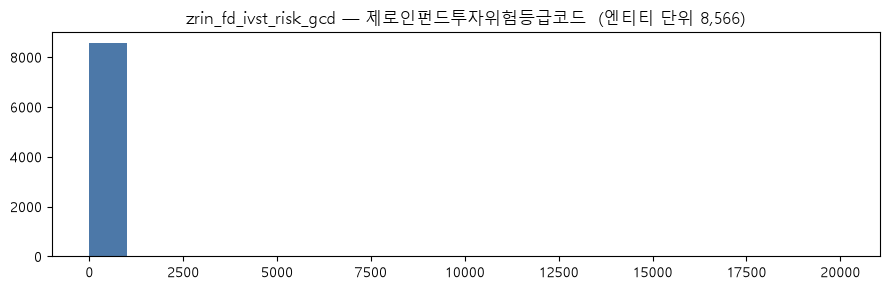

In [21]:
# ── 자유 탐색 ─────────────────────────────────────────────
# 관심 컬럼 하나를 골라 분포를 봅니다.
#
#   dist("<수치컬럼>")              분포 (엔티티 단위)
#   dist("<수치컬럼>", log=True)     꼬리가 길면 로그 스케일
#   dist("<범주컬럼>")              값 분포
#   display(corr_num())            수치형 상관 — 기간별 수익률 정합성 등
#
_cand = NUM.sort_values("왜곡배수", key=lambda s: (s - 1).abs(), ascending=False)
if len(_cand):
    _c = _cand.iloc[0]["column"]
    print(f"왜곡이 가장 큰 수치 컬럼: {_c} ({kor(_c)})\n")
    dist(_c)

---

# 🔗 컬럼 패밀리 — 컬럼끼리 무슨 관계인가

여기까지는 **컬럼 하나씩** 봤습니다. 그런데 컬럼 하나로는 답이 안 나오는 질문들이 있습니다.

| 질문 | 왜 컬럼 하나로는 안 되나 |
| :--- | :--- |
| 1년·3년·5년 수익률은 **누적인가 연환산인가** | 한 컬럼만 보면 그냥 숫자입니다. **기간 간 관계**를 봐야 드러납니다 |
| 코드 컬럼과 이름 컬럼이 **1:1로 맞물리나** | 각각은 멀쩡해 보여도, 맞춰보면 코드 6종에 라벨 8종입니다 |
| 20자리 코드의 **어느 자리가 무슨 뜻인가** | 값 목록을 봐야 아니라, **자릿수 구조**를 봐야 합니다 |
| 코드는 있는데 **이름 컬럼이 아예 없는** 축은? | 짝을 맞춰봐야 빈자리가 보입니다 (§5-A 운용사 문제) |

이 절의 결론은 `derivation_rules` · `canonical_*` · `unit` 으로 나갑니다.
그래서 🧬 엔티티 탐색 **앞**에 둡니다 — 패밀리 구조가 엔티티 분해의 재료입니다.

> ⚠️ **도구는 사실과 후보만 냅니다.** 단위 판정·코드 의미는 원본 `*_schema.xlsx` 와
> 대조해 사람이 정하고, `<domain>.yaml` 에 씁니다.

In [22]:
# ═══════════════════════════════════════════════════════════
# 1) 패밀리 자동 추출 — 컬럼명에서 관계를 읽는다
# ═══════════════════════════════════════════════════════════
# 자리표시자 조건은 프로파일러가 단일 정의를 갖습니다 (노트북에서 재정의 금지)
from profile_table import PLACEHOLDER_ZERO_SQL, PLACEHOLDER_MARK_SQL   # noqa: E402

# 기간 토큰 — 두 가지 표기 순서를 모두 봅니다
#   접두형  fd_wk1_ern_r · fd_mm18_ern_r · fd_yr5_ern_r   (public_funds)
#   접미형  du_er_1y · du_er_3m · du_er_6m                (domestic_etfs)
_UNIT_YEARS = {"wk": 1 / 52, "w": 1 / 52, "mm": 1 / 12, "m": 1 / 12,
               "yr": 1.0, "y": 1.0, "d": 1 / 365}
_PERIOD_RES = [re.compile(r"(?:^|_)(wk|mm|yr)(\d+)(?=_|$)", re.I),      # 접두형
               re.compile(r"(?:^|_)(\d+)(wk|mm|yr|w|m|y|d)(?=_|$)", re.I)]  # 접미형

# 코드 계열 / 이름 계열 접미사 — 짝을 맞추기 위해 어간에서 걷어냅니다
_CODE_SUF = ("gcd", "pcd", "tcd", "ccd", "cd", "code", "no", "id")
_NAME_SUF = ("nm", "name", "desc", "descr")
_STRIP_SUF = _CODE_SUF + _NAME_SUF + ("grd", "grade", "g", "abrv", "eng", "kor")


def _period(col):
    """컬럼명에서 기간을 읽는다 → (연 단위 기간, 토큰) 또는 None."""
    for i, rx in enumerate(_PERIOD_RES):
        m = rx.search(col)
        if not m:
            continue
        unit, num = (m.group(1), m.group(2)) if i == 0 else (m.group(2), m.group(1))
        u = _UNIT_YEARS.get(unit.lower())
        if u:
            return round(int(num) * u, 4), m.group(0).strip("_")
    return None


def _stem(col, strip=_STRIP_SUF):
    """접미사를 반복해서 걷어낸 어간. zrin_..._gcd 와 zrin_..._grd_nm 을 같은 어간으로 만든다."""
    parts = col.lower().split("_")
    while len(parts) > 1 and parts[-1] in strip:
        parts.pop()
    return "_".join(parts)


def families(verbose=True):
    """
    컬럼명에서 패밀리를 자동 추출한다.

      series      같은 측정량의 기간 시리즈   → series_shape()
      code_name   코드 ↔ 이름 쌍             → codebook()
      orphan      짝이 없는 코드/이름 컬럼     ← 🔴 여기가 자주 문제입니다
      flag        _yn 플래그군
    """
    ser, code, name = {}, {}, {}
    for c in COLS:
        p = _period(c)
        if p:
            ser.setdefault(_stem(c.lower().replace(p[1], "").replace("__", "_").strip("_"),
                                 strip=()), []).append((c, p[0]))
            continue
        last = c.lower().split("_")[-1]
        if last in _CODE_SUF:
            code.setdefault(_stem(c), []).append(c)
        elif last in _NAME_SUF:
            name.setdefault(_stem(c), []).append(c)

    ser = {k: sorted(v, key=lambda t: t[1]) for k, v in ser.items() if len(v) > 1}
    pairs = {k: (code[k], name[k]) for k in set(code) & set(name)}
    orphan_c = {k: v for k, v in code.items() if k not in pairs}
    orphan_n = {k: v for k, v in name.items() if k not in pairs}
    flags = [c for c in COLS if c.lower().endswith("_yn")]

    if verbose:
        print(f"■ 기간 시리즈 {len(ser)}개")
        for k, v in ser.items():
            print(f"    {k:<16} {len(v)}컬럼  " +
                  " → ".join(f"{t}y" for _, t in v))
            print(f"    {'':<16}        {', '.join(c for c, _ in v)}")
        print(f"\n■ 코드 ↔ 이름 쌍 {len(pairs)}개  → codebook() 으로 1:1 검증")
        for k, (cc, nn) in pairs.items():
            print(f"    {k:<24} {', '.join(cc)}  ↔  {', '.join(nn)}")
        print(f"\n■ 🔴 짝 없는 코드 컬럼 {len(orphan_c)}개 — 이름이 없으면 사용자 질의어와 못 잇습니다")
        for k, v in orphan_c.items():
            for c in v:
                print(f"    {c:<24} {kor(c)}  (distinct {AUTO['columns'][c]['distinct_count']:,})")
        print(f"\n■ 짝 없는 이름/설명 컬럼 {len(orphan_n)}개 — 코드가 없으니 문자열이 곧 키입니다")
        print("    " + ", ".join(c for v in orphan_n.values() for c in v))
        print(f"\n■ 플래그군 _yn {len(flags)}개: {', '.join(flags)}")
    return dict(series=ser, code_name=pairs, orphan_code=orphan_c,
                orphan_name=orphan_n, flag=flags)

## 기간 시리즈 — 누적인가 연환산인가

> 🔴 **이 판정이 틀리면 답변이 3배 틀립니다.** *"3년 수익률 10.5%"* 를 연 10.5%로 읽으면
> 실제 누적 10.5%인 상품이 3배 좋아 보입니다.

`series_shape()` 는 두 가설을 데이터로 겨룹니다.

```
로그수익률  L = ln(1 + r/100)
가설① 누적    → 연환산하면 L/n 이 기간 간 일정해야 함
가설② 연환산  → L 이 그대로 기간 간 일정해야 함
                 각각의 기간 간 표준편차를 비교 → 작은 쪽이 데이터에 맞음
```

> ⚠️ **1년 미만 기간은 반드시 제외합니다 (`min_years=1.0` 기본값).**
> 누적 가설에서 1주 수익률의 연환산은 `(1+r)^52` 라 값이 폭발하고,
> 그 분산이 가설①을 구조적으로 불리하게 만듭니다. 공모펀드 실측:
>
> | 조건 | 가설① 누적 | 가설② 연환산 | 판정 |
> | :--- | ---: | ---: | :--- |
> | 전 기간(1주~5년) | 0.3295 | 0.1726 | ❌ **연환산 — 편향된 오답** |
> | **1년 이상만** | **0.0675** | 0.0900 | ✅ 누적 |
>
> **분산 비교 하나만 믿지 마세요.** 그래서 도구가 저변동군 복리 대조를 함께 냅니다 —
> 손실이 없는 상품군(MMF 등)은 복리가 그대로 드러나 결정적 증거가 됩니다.

In [23]:
# ═══════════════════════════════════════════════════════════
# 2) 기간 시리즈 해부 — 누적/연환산 · 중첩 위반 · 단조성
# ═══════════════════════════════════════════════════════════
def series_shape(stem=None, group_col=None, min_years=1.0, min_n=30):
    """
    기간 시리즈의 성질을 판정 재료로 낸다.

      ① 단위 가설    누적 vs 연환산 (로그 스케일, 1년 미만 제외)
      ② 복리 대조    저변동 하위군에서 (1+r₁)ⁿ 예측 vs 실측  ← 결정적 증거
      ③ 중첩 위반    긴 기간 값은 있는데 짧은 기간이 없는 종목
      ④ 단조성      기간이 길수록 |수익률| 이 커지는 비율

    stem 미지정이면 families() 의 첫 시리즈를 씁니다.
    group_col 미지정이면 저카디널리티 범주형 중 변동이 가장 낮은 그룹을 자동 선택합니다.
    """
    F = families(verbose=False)["series"]
    if not F:
        print("기간 토큰(wk1·mm3·1y…)을 가진 컬럼 패밀리가 없습니다")
        return None
    stem = stem or next(iter(F))
    fam = F[stem]
    print(f"■ 패밀리 '{stem}' — {len(fam)}컬럼\n")

    use = [(c, n) for c, n in fam if n >= min_years]
    dropped = [c for c, n in fam if n < min_years]
    if dropped:
        print(f"  1년 미만 {len(dropped)}컬럼 제외 (연환산 시 값 폭발 → 가설① 불리): "
              f"{', '.join(dropped)}")
    if len(use) < 2:
        print("  1년 이상 컬럼이 2개 미만이라 단위 판정을 할 수 없습니다")
        return None

    cols = [c for c, _ in use]
    sel = ", ".join(f'MAX("{c}") AS "{c}"' for c in cols)
    gsel = f', MAX(TRIM(CAST("{group_col}" AS TEXT))) AS __g' if group_col else ""
    key = ENTITY_KEY or COLS[0]
    d = q(f'SELECT "{key}" AS __k, {sel}{gsel} FROM {DOMAIN} GROUP BY "{key}"')
    full = d[cols].dropna()
    print(f"  전 기간 값 보유 {len(full):,}개 / {len(d):,}개\n")
    if len(full) < min_n:
        print("  표본이 부족합니다")
        return None

    # ── ① 단위 가설 ──
    L = pd.DataFrame({c: np.log((1 + full[c] / 100).clip(lower=1e-9)) for c in cols})
    ann = pd.DataFrame({c: L[c] / n for c, n in use})          # 누적 가설 → 연환산
    cum_sd, ann_sd = L.std(axis=1).median(), ann.std(axis=1).median()
    verdict = "누적(cumulative)" if ann_sd < cum_sd else "연환산(annualized)"
    print(f"  ① 단위 가설  누적 {ann_sd:.4f}  vs  연환산 {cum_sd:.4f}"
          f"   → 🔎 {verdict} 쪽이 일관적")

    # ── ② 복리 대조 (저변동군) ──
    # 🔴 후보 컬럼 하나만 보면 안 됩니다. 첫 실행에서 curr_cd 만 보고 'KRW'(std 82.95,
    #    사실상 전체 모집단)를 저변동군으로 골라 대조가 무의미해졌습니다.
    #    전 후보 컬럼 × 전 그룹을 훑어야 MMF 같은 진짜 저변동군이 나옵니다.
    base, n1 = cols[0], use[0][1]
    cands = ([group_col] if group_col else
             [c for c, e in AUTO["columns"].items()
              if e["kind"] == "text" and 2 <= e["distinct_count"] <= 20])
    sub = low = None
    if cands:
        gsel = ", ".join(f'MAX(TRIM(CAST("{c}" AS TEXT))) AS "g_{c}"' for c in cands)
        g = q(f'SELECT "{key}" AS __k, {gsel} FROM {DOMAIN} GROUP BY "{key}"')
        m = d[["__k"] + cols].dropna().merge(g, on="__k")
        found = []
        for gc in cands:
            st = m.groupby(f"g_{gc}")[base].agg(["count", "std"])
            st = st[st["count"] >= min_n].dropna()
            for v, r in st.iterrows():
                found.append((float(r["std"]), gc, v, int(r["count"])))
        if found:
            found.sort()
            sd, gc, v, cnt = found[0]
            sub, low = m[m[f"g_{gc}"] == v], f"{gc}={v}"
            print(f"\n  ② 복리 대조 — 후보 {len(cands)}컬럼 {len(found)}그룹을 훑어 "
                  f"변동이 가장 낮은 그룹 선택")
            print(f"      선택 '{low}'  n={cnt:,}  std={sd:.2f}")
            print(f"      차순위: " + " · ".join(f"{c}={x} std {s:.1f}" for s, c, x, _ in found[1:4]))

    if sub is not None and len(sub):
        r1 = sub[base].median() / 100
        print(f"\n      {'기간':>6} {'실측':>10} {'누적예측':>10} {'연환산예측':>10}")
        e_cum, e_ann = [], []
        for c, n in use:
            obs = sub[c].median()
            p_cum = ((1 + r1) ** (n / n1) - 1) * 100
            p_ann = r1 * 100
            print(f"      {n:>5.1f}y {obs:>10.2f} {p_cum:>10.2f} {p_ann:>10.2f}")
            lg = lambda x: np.log(max(1 + x / 100, 1e-9))
            e_cum.append(abs(lg(obs) - lg(p_cum)))
            e_ann.append(abs(lg(obs) - lg(p_ann)))
        mc, ma = float(np.mean(e_cum)), float(np.mean(e_ann))
        print(f"      예측 오차(로그)  누적 {mc:.3f}  vs  연환산 {ma:.3f}"
              f"   → 🔎 {'누적' if mc < ma else '연환산'} 지지")
        if (mc < ma) != (ann_sd < cum_sd):
            print("      ⚠️ ①과 ②의 결론이 엇갈립니다 — 원본 schema 의 단위 정의를 직접 확인하세요")

    # ── ③ 결측 패턴 — '아직 없는 것' 과 '안 넣은 것' 을 가른다 ──
    # 🔑 설정일 컬럼이 없어도 중첩 패턴이 상품 나이를 알려줍니다.
    #    짧은 기간부터 차례로 채워졌으면 '아직 그 기간이 안 된 것'(구조적 = not_applicable),
    #    중간에 구멍이 나면 운용기간으로 설명되지 않습니다(= 데이터 문제).
    allc = [c for c, _ in fam]
    asel = ", ".join(f'MAX("{c}") AS "{c}"' for c in allc)
    a = q(f'SELECT "{key}" AS __k, {asel} FROM {DOMAIN} GROUP BY "{key}"')
    Mx = a[allc].notna().to_numpy()

    def _shape(r):
        if r.all():
            return "완전"
        if not r.any():
            return "전무"
        k = int(r.sum())
        return "접미결측(신생형)" if r[:k].all() and not r[k:].any() else "구멍"

    a["__p"] = [_shape(r) for r in Mx]
    vc = a["__p"].value_counts()
    print("\n  ③ 결측 패턴 — 짧은 기간부터 순서대로 채워졌는가")
    for k in ("완전", "접미결측(신생형)", "전무", "구멍"):
        if k in vc:
            tag = {"접미결측(신생형)": "← 아직 그 기간이 안 됨 (not_applicable)",
                   "전무": "← 이 상품엔 시리즈 자체가 없음 (아래 대조 참조)",
                   "구멍": "🔴 운용기간으로 설명 안 됨"}.get(k, "")
            print(f"      {k:<14} {vc[k]:>7,}종목 ({vc[k] / len(a):>5.1%})  {tag}")
    ok = sum(vc.get(k, 0) for k in ("완전", "접미결측(신생형)", "전무"))
    print(f"      → 운용기간·미보유로 설명되는 종목 {ok:,}/{len(a):,} ({ok / len(a):.1%})")

    if "접미결측(신생형)" in vc:
        suf = pd.Series(Mx[a["__p"].to_numpy() == "접미결측(신생형)"].sum(axis=1))
        s = suf.value_counts().sort_index()
        print("      접미결측이 어디서 끊기나: " +
              " · ".join(f"{allc[i - 1].split('_')[-3] if False else allc[i - 1]}까지 {n:,}"
                         for i, n in s.items() if i >= 1))
    if "구멍" in vc:
        pat = pd.Series(["".join("O" if x else "·" for x in r)
                         for r in Mx[a["__p"].to_numpy() == "구멍"]]).value_counts()
        print(f"      구멍 패턴 {len(pat)}종 (짧은기간→긴기간). 상위 3:")
        for p, n in pat.head(3).items():
            print(f"         {p}   {n:,}종목")

    # 패턴별로 '다른 컬럼' 의 값 보유율이 갈리는지 — 전무가 신생인지 미평가인지 가른다
    others = [c for c in COLS if c not in allc and c != key][:40]
    if others and len(vc) > 1:
        o = q(f'SELECT "{key}" AS __k, ' + ", ".join(f'MAX("{c}") AS "{c}"' for c in others)
              + f' FROM {DOMAIN} GROUP BY "{key}"')
        mo = a[["__k", "__p"]].merge(o, on="__k")
        rate = mo.groupby("__p")[others].apply(lambda g: g.notna().mean())
        spread = (rate.max() - rate.min()).sort_values(ascending=False)
        top = [c for c in spread.index[:5] if spread[c] > 0.1]
        if top:
            print("\n      패턴별 값 보유율이 가장 크게 갈리는 컬럼 — 결측의 정체가 여기서 드러납니다")
            display(rate[top].round(3))
            print("      한 패턴만 보유율이 낮으면 그 그룹은 '신생' 이 아니라 "
                  "'데이터 소스 자체가 없는' 그룹입니다")

    # ── ④ 단조성 ──
    # 전체 모집단에서 재면 손실 구간 때문에 누적이어도 50% 근처가 나옵니다.
    # 손실이 거의 없는 저변동군에서만 판별력이 있습니다.
    inc_all = (full[cols].abs().diff(axis=1).iloc[:, 1:] > 0).mean(axis=1).median()
    print(f"\n  ④ 단조성 — 기간이 길수록 |수익률| 이 커지는 비율 (중앙값)")
    print(f"      전체     {inc_all:.0%}   ← 손실 구간 때문에 누적이어도 50% 근처. 판별력 낮음")
    if sub is not None and len(sub):
        inc_low = (sub[cols].abs().diff(axis=1).iloc[:, 1:] > 0).mean(axis=1).median()
        print(f"      저변동군 {inc_low:.0%}   ← 손실이 없으면 누적일 때 100%에 가깝습니다 ({low})")
    return dict(stem=stem, verdict=verdict, cum_sd=cum_sd, ann_sd=ann_sd,
                patterns=a[["__k", "__p"]].rename(columns={"__k": "entity", "__p": "패턴"}))

## 코드 ↔ 이름 — 맞물리는가

코드 컬럼과 이름 컬럼은 각각 보면 멀쩡합니다. **맞춰봐야 어긋난 게 보입니다.**

| 어긋남 | 뜻 | 대응 |
| :--- | :--- | :--- |
| 코드 1 → 이름 2개 이상 | **표기 흔들림** (`높은 위험` / `높은위험`) | 정규화 규칙. 소수 쪽이 대개 오염 |
| 이름 1 → 코드 2개 이상 | 코드가 더 세분됐거나 코드 쪽 오염 | 어느 쪽을 키로 쓸지 결정 |
| 코드는 있는데 이름 없음 | **질의어와 못 이음** | 외부 매핑 필요 (§5-A 운용사 코드 67종) |

`codebook()` 의 출력이 그대로 `<domain>.yaml` 의 `canonical_*` 재료가 됩니다.

In [24]:
# ═══════════════════════════════════════════════════════════
# 3) 코드북 — 코드 ↔ 이름 매핑과 어긋남
# ═══════════════════════════════════════════════════════════
def codebook(code_col, name_col=None, top=30):
    """코드↔이름 매핑표 + 1:1 어긋남. name_col 미지정이면 어간으로 짝을 찾습니다."""
    if name_col is None:
        pairs = families(verbose=False)["code_name"].get(_stem(code_col))
        if not pairs or code_col not in pairs[0]:
            print(f"{code_col}: 짝 이름 컬럼을 못 찾았습니다. name_col 을 직접 주세요.\n"
                  f"  → 이름 컬럼이 정말 없다면 그 자체가 발견입니다 (질의어와 못 이음)")
            return None
        name_col = pairs[1][0]
    print(f"■ {code_col} ({kor(code_col)})  ↔  {name_col} ({kor(name_col)})\n")

    key = ENTITY_KEY or COLS[0]
    mp = q(f"""SELECT TRIM(CAST("{code_col}" AS TEXT)) AS 코드,
                      TRIM(CAST("{name_col}" AS TEXT)) AS 이름,
                      COUNT(DISTINCT "{key}") AS 개체수
               FROM {DOMAIN}
               WHERE TRIM(COALESCE(CAST("{code_col}" AS TEXT),'')) <> ''
               GROUP BY 1,2 ORDER BY 1, 3 DESC""")
    display(mp.head(top))
    if len(mp) > top:
        print(f"… {len(mp) - top}행 생략 (top={top})")

    for a, b, label, hint in (("코드", "이름", "표기 흔들림", "소수 쪽이 대개 오염입니다 — 정규화 규칙으로"),
                              ("이름", "코드", "코드 세분/오염", "어느 쪽을 키로 쓸지 정하세요")):
        bad = mp.groupby(a)[b].nunique()
        bad = bad[bad > 1]
        if not len(bad):
            print(f"\n  ✅ {a} 하나에 {b} 하나 — 1:1 입니다")
            continue
        print(f"\n  🔴 {label} — {a} {len(bad)}종이 {b}를 여러 개 가집니다 ({hint})")
        for v in bad.index:
            sub = mp[mp[a] == v].sort_values("개체수", ascending=False)
            items = " · ".join(f"{r[b]!r} {r['개체수']:,}" for _, r in sub.iterrows())
            print(f"      {a} {v!r:<12} → {items}")
    return mp

## 고정길이 코드 — 어느 자리가 무슨 뜻인가

20자리 계층코드, 8자리 기관코드처럼 **자릿수에 의미가 실린 코드**가 있습니다.
값 목록을 아무리 봐도 안 보이고, **자릿수 구조**를 봐야 드러납니다.

`code_layout()` 이 보는 것:

```
접두사 길이별 distinct 증가 곡선
   길이 1→2 에서 distinct 가 2→18 로 뛰면  그 자리가 새 세그먼트의 시작
   길이 8→9 에서 안 늘면                   8자리에서 의미가 끝남
자리별 문자 집합
   숫자만 / 영문 포함 / 'Z' 같은 미사용 표시가 특정 구간에만 나타나는지
세그먼트별 분기 수
   상위 접두사 하나당 하위가 몇 갈래인지 → 계층인지 평면인지
```

> 자리표시자 값(`'0'×20` 등)은 **제외하고 셉니다.** 안 그러면 그 값 하나가
> 모든 자리의 distinct 를 1로 끌어내려 구조가 안 보입니다.

In [25]:
# ═══════════════════════════════════════════════════════════
# 4) 고정길이 코드 해부
# ═══════════════════════════════════════════════════════════
def code_layout(col, max_len=24, jump=1.5):
    """
    고정길이 코드의 자릿수 구조를 추정한다.

    세그먼트 경계 = 접두사를 한 자 늘렸을 때 distinct 가 `jump` 배 넘게 뛰는 지점.
    자리별 distinct 만 보는 것보다 낫습니다 — 계층 코드는 상위가 같아야 하위가
    의미를 갖기 때문에, 자리 단독 분포로는 경계가 안 보입니다.
    """
    where = (f'TRIM(COALESCE(CAST("{col}" AS TEXT),\'\')) <> \'\''
             f' AND NOT ({PLACEHOLDER_ZERO_SQL.format(c=chr(34) + col + chr(34))})'
             f' AND NOT ({PLACEHOLDER_MARK_SQL.format(c=chr(34) + col + chr(34))})')
    lens = q(f"""SELECT LENGTH(TRIM(CAST("{col}" AS TEXT))) AS 길이, COUNT(*) AS n
                 FROM {DOMAIN} WHERE {where} GROUP BY 1 ORDER BY 2 DESC""")
    if lens.empty:
        print(f"{col}: 자리표시자를 빼면 값이 없습니다")
        return None
    print(f"■ {col} ({kor(col)}) — 길이 분포")
    display(lens.head(5))
    n = int(lens.iloc[0]["길이"])
    if n > max_len:
        print(f"  길이 {n} 이 상한 {max_len} 초과 — 앞 {max_len}자리만 봅니다")
        n = max_len

    rows, prev = [], 1
    for i in range(1, n + 1):
        r = q(f"""SELECT COUNT(DISTINCT SUBSTR(TRIM(CAST("{col}" AS TEXT)),1,{i})) AS 누적,
                         COUNT(DISTINCT SUBSTR(TRIM(CAST("{col}" AS TEXT)),{i},1)) AS 자리,
                         GROUP_CONCAT(DISTINCT SUBSTR(TRIM(CAST("{col}" AS TEXT)),{i},1)) AS 값
                  FROM {DOMAIN} WHERE {where}""").iloc[0]
        cum = int(r.누적)
        rows.append(dict(자리=i, 누적distinct=cum, 배수=round(cum / prev, 2),
                         자리distinct=int(r.자리), 경계="", 값=str(r.값)[:30]))
        prev = max(cum, 1)
    df = pd.DataFrame(rows)
    # 앞자리는 distinct 가 자명하게 늘어납니다 — '완만해졌다가 다시 뛰는' 지점만 경계로 봅니다.
    # 그냥 배수 >= jump 로 잡으면 1~6자리가 전부 경계로 나와 신호가 사라집니다.
    for i in range(1, len(df)):
        if df.at[i, "배수"] >= jump and df.at[i - 1, "배수"] < jump:
            df.at[i, "경계"] = "◀ 세그먼트 시작"
    bnds = df[df["경계"] != ""]["자리"].tolist()
    display(df)

    print(f"  추정 세그먼트 경계: {bnds or '뚜렷한 경계 없음 (평면 코드일 가능성)'}")
    flat = df[(df["배수"] <= 1.02) & (df["자리"] > 1)]["자리"].tolist()
    if flat:
        print(f"  거의 안 늘어나는 자리 {flat} — 이 뒤는 의미가 없거나 패딩일 수 있습니다")

    # 특정 자리부터만 나타나는 문자 — 미사용 표시(Z 등)는 코드가 짧게 쓰였다는 신호
    seen, late = set(), {}
    for _, r in df.iterrows():
        for ch in str(r["값"]).split(","):
            ch = ch.strip()
            if ch and ch not in seen:
                seen.add(ch)
                late.setdefault(int(r["자리"]), []).append(ch)
    tail = {k: v for k, v in late.items() if k >= 3}
    if tail:
        print("  자리별 첫 등장 문자 (3자리 이후) — 뒤에서만 나오는 문자는 미사용 표시일 수 있습니다")
        for k, v in sorted(tail.items()):
            print(f"      {k:>2}자리부터  {', '.join(v)}")
    print("  ⚠️ 추정입니다. 원본 schema 엑셀의 코드 정의와 반드시 대조하세요.")
    return df

# ═══════════════════════════════════════════════════════════
# 5) 코드 축 해독 — 미해독 코드가 기존 어떤 컬럼과 대응하는가
# ═══════════════════════════════════════════════════════════
def axis_decode(col, pattern=r"^([A-Za-z]+)(\d+)$", min_gain=0.10, top=3, min_n=30):
    """
    코드 컬럼을 축(문자)별로 갈라, 각 축이 **기존 어떤 컬럼과 대응하는지** 찾는다.

    🔴 상호정보량(NMI)만 보면 안 됩니다. 한쪽으로 치우친 컬럼에서 값이 부풀어,
       공모펀드 실측에서 C축(설정유형 NMI 0.75)·O축(파생 NMI 0.61)을 오판했습니다.
       실제로는 둘 다 '그냥 최빈값으로 찍기' 와 차이가 없었습니다(이득 +0.05, +0.03).

        순도   축 값을 알 때 그 컬럼을 맞히는 비율
        기준선 그냥 최빈값으로 찍었을 때의 비율
        이득   순도 − 기준선          ← 이것만 정보량이다

    순도가 낮아도 이득이 크면 대응입니다. 반대로 순도 0.99 라도 기준선이 0.94 면
    아무 정보가 없습니다. 그리고 **축이 상대 컬럼보다 세분이면 순도는 낮게 나옵니다** —
    그 경우 '몇 갈래로 쪼개는지' 를 함께 봐야 합니다.
    """
    if not ENTITY_KEY:
        print("엔티티 키 미확정 — 🧱 구조 검증을 먼저 하세요")
        return None
    tags = q(f'SELECT DISTINCT "{ENTITY_KEY}" AS k, TRIM(CAST("{col}" AS TEXT)) AS t '
             f'FROM {DOMAIN} WHERE TRIM(COALESCE(CAST("{col}" AS TEXT),\'\')) <> \'\'')
    ex = tags["t"].str.extract(pattern)
    tags = tags[ex[0].notna()].assign(축=ex[0])
    if tags.empty:
        print(f"{col}: 패턴 {pattern} 에 맞는 값이 없습니다")
        return None

    cands = [c for c, e in AUTO["columns"].items()
             if c != col and 2 <= e["distinct_count"] <= 50]
    if not cands:
        print("대조할 저카디널리티 컬럼이 없습니다")
        return None
    base = q(f'SELECT "{ENTITY_KEY}" AS k, '
             + ", ".join(f'MAX(TRIM(CAST("{c}" AS TEXT))) AS "{c}"' for c in cands)
             + f' FROM {DOMAIN} GROUP BY "{ENTITY_KEY}"')

    out = []
    for ax, g in tags.groupby("축"):
        v = g.groupby("k")["t"].apply(lambda s: "+".join(sorted(s))).rename("값")
        m = base.set_index("k").join(v, how="inner")
        if len(m) < min_n:
            continue
        rows = []
        for c in cands:
            s = m[m[c].notna() & (m[c] != "")]
            if len(s) < min_n or s[c].nunique() < 2:
                continue
            ct = pd.crosstab(s["값"], s[c])
            pur = ct.max(axis=1).sum() / ct.to_numpy().sum()
            bl = s[c].value_counts(normalize=True).max()
            rows.append((pur - bl, pur, bl, c, len(s), int(s[c].nunique())))
        rows.sort(reverse=True)
        for gain, pur, bl, c, n, nv in rows[:top]:
            out.append(dict(축=ax, 값종류=m["값"].nunique(), 종목=len(m), 대조컬럼=c,
                            상대값종류=nv, 순도=round(pur, 3), 기준선=round(bl, 3),
                            이득=round(gain, 3), 모수=n,
                            판정=("✅ 대응" if gain >= 0.30 else
                                  "🔶 부분" if gain >= min_gain else "❌ 무의미")))
    df = pd.DataFrame(out)
    if df.empty:
        print("판정할 축이 없습니다")
        return df
    hit = df[df["판정"] != "❌ 무의미"]
    print(f"■ {col} — 축 {df['축'].nunique()}개 중 대응이 잡힌 축 {hit['축'].nunique()}개")
    print("   순도가 높아도 기준선이 높으면 정보가 없습니다. 이득 열을 보세요.")
    return df.sort_values("이득", ascending=False).reset_index(drop=True)


def axis_split(col, axis, by, pattern=r"^([A-Za-z]+)(\d+)$"):
    """축이 상대 컬럼을 '몇 갈래로 쪼개는지' — 세분 축인지 확인한다."""
    t = q(f'SELECT DISTINCT "{ENTITY_KEY}" AS k, TRIM(CAST("{col}" AS TEXT)) AS t '
          f'FROM {DOMAIN} WHERE TRIM(CAST("{col}" AS TEXT)) GLOB \'{axis}[0-9]*\'')
    b = q(f'SELECT "{ENTITY_KEY}" AS k, MAX(TRIM(CAST("{by}" AS TEXT))) AS b '
          f'FROM {DOMAIN} GROUP BY "{ENTITY_KEY}"')
    m = t.merge(b, on="k")
    ct = pd.crosstab(m["t"], m["b"])
    print(f"■ 축 {axis} 가 {by} 를 쪼개는 정도")
    for v in ct.columns:
        n = int((ct[v] > 0).sum())
        if n:
            print(f"   {by}='{v}' ({int(ct[v].sum()):,}종목) → 축 {axis} 값 {n}종으로 분할")
    return ct


print("코드 해독: axis_decode(col) · axis_split(col, 축문자, 대조컬럼)")

코드 해독: axis_decode(col) · axis_split(col, 축문자, 대조컬럼)


## 실행

아래는 담당 테이블에서 자동으로 잡히는 것만 돌립니다. **결론은 `_notes.md` 로 옮기세요.**

- `series_shape` 의 `verdict` 와 복리 대조 → `<domain>.yaml` 의 `unit`
- `codebook` 의 표기 흔들림 → `normalization` · `canonical_*`
- `code_layout` 의 세그먼트 경계 → `derivation_rules` (코드에서 축을 유도)
- **짝 없는 코드 컬럼** → 워크샵 안건 (§3 질문 3·4)

In [26]:
# ── 실행 ① 패밀리 훑기 ────────────────────────────────────
FAM = families()

# ── 실행 ② 기간 시리즈 ────────────────────────────────────
if FAM["series"]:
    print("\n" + "═" * 62)
    SER = series_shape()

# ── 실행 ③ 코드북 — 짝이 있는 것 전부 ──────────────────────
for _stem_k, (_cc, _nn) in FAM["code_name"].items():
    print("\n" + "═" * 62)
    codebook(_cc[0], _nn[0])

# ── 실행 ④ 고정길이 코드 — 가장 긴 코드 컬럼 하나 ───────────
_codes = [c for c, e in AUTO["columns"].items()
          if e["kind"] == "text" and e["distinct_count"] > 20
          and c.lower().split("_")[-1] in _CODE_SUF]
if _codes:
    _longest = max(_codes, key=lambda c: len(str((AUTO["columns"][c].get("values_top")
                                                  or AUTO["columns"][c].get("values")
                                                  or [{"value": ""}])[0]["value"])))
    print("\n" + "═" * 62)
    LAY = code_layout(_longest)
    print(f"\n다른 코드도 보려면: code_layout('<컬럼명>')  후보 {len(_codes)}개: "
          f"{', '.join(_codes[:8])}{' …' if len(_codes) > 8 else ''}")

■ 기간 시리즈 1개
    fd_ern_r         9컬럼  0.0192y → 0.0833y → 0.25y → 0.5y → 1.0y → 1.5y → 2.0y → 3.0y → 5.0y
                            fd_wk1_ern_r, fd_mm1_ern_r, fd_mm3_ern_r, fd_mm6_ern_r, fd_yr1_ern_r, fd_mm18_ern_r, fd_yr2_ern_r, fd_yr3_ern_r, fd_yr5_ern_r

■ 코드 ↔ 이름 쌍 2개  → codebook() 으로 1:1 검증
    itm                      itm_no  ↔  itm_abrv_nm, itm_eng_nm, itm_nm
    zrin_fd_ivst_risk        zrin_fd_ivst_risk_gcd  ↔  zrin_fd_ivst_risk_grd_nm

■ 🔴 짝 없는 코드 컬럼 13개 — 이름이 없으면 사용자 질의어와 못 잇습니다
    curr_cd                  통화코드  (distinct 2)
    fd_estb_ctry_cd          펀드설립국가코드  (distinct 2)
    fd_set_pcd               펀드설정유형코드  (distinct 3)
    fss_itm_no               금융감독원종목번호  (distinct 8,086)
    kofia_fd_ccd             금융투자협회펀드분류코드  (distinct 4,782)
    ksd_itm_no               예탁원종목번호  (distinct 11,092)
    mtco_itm_no              운용사종목번호  (distinct 4,660)
    or_co_xtn_itt_cd         운용회사대외기관코드  (distinct 67)
    pfiv_sale_cntl_tcd       전문투자자판매제어구분코드  (distinct 3)
    prfd_a

,zrin_fd_ivst_risk_gcd,zrin_fd_ivst_risk_grd_nm,fd_nast_suma,thco_sale_yn,exchdg_yn
__p,,,,,
구멍,1.000,1.000,1.000,0.992,0.701
완전,1.000,1.000,1.000,0.991,0.611
전무,0.273,0.273,0.477,0.820,0.591
접미결측(신생형),1.000,1.000,1.000,0.997,0.697


      한 패턴만 보유율이 낮으면 그 그룹은 '신생' 이 아니라 '데이터 소스 자체가 없는' 그룹입니다

  ④ 단조성 — 기간이 길수록 |수익률| 이 커지는 비율 (중앙값)
      전체     50%   ← 손실 구간 때문에 누적이어도 50% 근처. 판별력 낮음
      저변동군 100%   ← 손실이 없으면 누적일 때 100%에 가깝습니다 (zrin_fd_ivst_risk_grd_nm=매우 낮은 위험)

══════════════════════════════════════════════════════════════
■ itm_no (종목번호)  ↔  itm_abrv_nm (종목약어명)



,코드,이름,개체수
0,"""",해당없음,1
1,KR5010101401,서울신종MMF1,1
2,KR5010101402,서울신종MMF2,1
3,KR5010101404,서울신종MMF4,1
4,KR5010101405,서울신종MMF5,1
5,KR5010101501,서울신종MMF101,1
6,KR5010101502,서울신종MMF102,1
7,KR5010101701,서울신종MMF301,1
8,KR5010101702,미래에셋국공채MMF투자신탁1호[국공채]C,1
9,KR5010101703,미래에셋국공채MMF1호[국공채]Cw,1


… 11109행 생략 (top=30)

  ✅ 코드 하나에 이름 하나 — 1:1 입니다

  🔴 코드 세분/오염 — 이름 13종이 코드를 여러 개 가집니다 (어느 쪽을 키로 쓸지 정하세요)
      이름 'KB국채10년목표전환증권투자(채-재)C퇴직' → 'KR5127490320' 1 · 'KR5127490321' 1
      이름 '국민디자인단기채권1' → 'KR511332201M' 1 · 'KR5127151001' 1
      이름 '국민디자인장기채권1' → 'KR511332401M' 1 · 'KR5127251001' 1
      이름 '다올중국플러스찬스증권(채권혼합)A' → 'KR5152430100' 1 · 'KR5152430101' 1 · 'KR5152430102' 1 · 'KR5152430103' 1 · 'KR5152430104' 1 · 'KR5152430106' 1 · 'KR5152430107' 1 · 'KR5152430109' 1
      이름 '대신디딤올라운드자산배분증권[혼-재간]CPe' → 'KR5124490011' 1 · 'KR5124490013' 1
      이름 '베어링글로벌선순위담보UH(채권재간접)CP2' → 'KR5156490072' 1 · 'KR5156490073' 1
      이름 '삼성KODEX중국CSI300' → 'KR5114601178' 1 · 'KR5114601179' 1
      이름 '삼성코리아단기채권자투자제1호(채권)C' → 'KR5114420051' 1 · 'KR5114420057' 1
      이름 '우리중소형고배당30증권1호(채-혼)Ce' → 'KR5118430026' 1 · 'KR5118430027' 1
      이름 '유진챔피언단기채증권자투자(채권)C-P2' → 'KR5122420004' 1 · 'KR5122420005' 1
      이름 '피델미국하이일채재A' → 'KR5148420120' 1 · 'KR5148420130' 1
      이름 '피델미국하이일채재C' → 'KR514842012

,코드,이름,개체수
0,1.0,매우 높은 위험,670
1,2.0,높은 위험,3281
2,2.0,높은위험,20
3,20054.0,06,1
4,3.0,다소 높은 위험,1663
5,4.0,보통 위험,1386
6,4.0,보통위험,8
7,5.0,낮은 위험,1199
8,6.0,매우 낮은 위험,338



  🔴 표기 흔들림 — 코드 2종이 이름를 여러 개 가집니다 (소수 쪽이 대개 오염입니다 — 정규화 규칙으로)
      코드 '2.0'        → '높은 위험' 3,281 · '높은위험' 20
      코드 '4.0'        → '보통 위험' 1,386 · '보통위험' 8

  ✅ 이름 하나에 코드 하나 — 1:1 입니다

══════════════════════════════════════════════════════════════
■ kofia_fd_ccd (금융투자협회펀드분류코드) — 길이 분포


,길이,n
0,20,73384
1,19,10


,자리,누적distinct,배수,자리distinct,경계,값
0,1,2,2.000,2,,"1,2"
1,2,15,7.500,9,,"1,4,2,9,6,3,E,8,7"
2,3,23,1.530,3,,"1,2,E"
3,4,48,2.090,3,,"1,2,3"
4,5,81,1.690,4,,"1,3,4,2"
5,6,461,5.690,19,,"A,2,6,4,7,B,9,Y,E,C,0,1,G,Z,H,"
6,7,502,1.090,6,,"3,1,9,2,4,6"
7,8,557,1.110,6,,"2,3,1,6,0,5"
8,9,796,1.430,10,,"7,0,3,4,9,1,6,8,A,2"
9,10,1275,1.600,9,◀ 세그먼트 시작,"3,0,6,1,2,4,5,7,8"


  추정 세그먼트 경계: [10]
  거의 안 늘어나는 자리 [19] — 이 뒤는 의미가 없거나 패딩일 수 있습니다
  자리별 첫 등장 문자 (3자리 이후) — 뒤에서만 나오는 문자는 미사용 표시일 수 있습니다
       6자리부터  A, B, Y, C, 0, G, Z, H
       8자리부터  5
      20자리부터  D
  ⚠️ 추정입니다. 원본 schema 엑셀의 코드 정의와 반드시 대조하세요.

다른 코드도 보려면: code_layout('<컬럼명>')  후보 8개: fss_itm_no, itm_no, kofia_fd_ccd, ksd_itm_no, mtco_itm_no, prfd_attr_cd, rptt_ksd_itm_no, std_itm_no


### 유도 규칙 검증 도구

엔티티·클래스를 유도하는 규칙이 **얼마나 커버하는지**, 표기가 **그룹 간 통용되는지** 봅니다.

In [27]:
# ═══════════════════════════════════════════════════════════
# 유도 규칙 검증
# ═══════════════════════════════════════════════════════════

def derive_coverage(fn, label="유도"):
    """유도 함수를 전 개체에 적용해 판정률과 분포를 낸다. fn(itm_nm, 범주값) -> 값 or None"""
    rows = q(f"SELECT DISTINCT {PK} AS pk, TRIM(itm_nm) AS nm, "
             f"TRIM(or_attr_desc) AS cat FROM {DOMAIN}")
    got = [fn(r.nm, r.cat) for r in rows.itertuples()]
    s = pd.Series(got)
    n_ok = s.notna().sum()
    print(f"[{label}] 판정 {n_ok:,} / {len(s):,} ({n_ok/len(s):.1%}) · 불명 {len(s)-n_ok:,}")
    return s.value_counts(dropna=False)


def vocab_reuse(extract_fn, group_col, min_share=2):
    """
    추출한 표기가 여러 그룹에 걸쳐 통용되는지.
    통용되면 그룹에 종속된 값이 아니라 **독립 어휘(=엔티티 후보)** 다.
    """
    rows = q(f"SELECT DISTINCT {PK} AS pk, TRIM(itm_nm) AS nm, "
             f'"{group_col}" AS g FROM {DOMAIN}')
    bag = {}
    for r in rows.itertuples():
        v = extract_fn(r.nm)
        if v:
            bag.setdefault(v, set()).add(r.g)
    df = pd.DataFrame([dict(표기=k, 사용그룹수=len(v)) for k, v in bag.items()])
    df = df.sort_values("사용그룹수", ascending=False)
    shared = (df["사용그룹수"] >= min_share).sum()
    print(f"표기 {len(df)}종 중 {shared}종이 {min_share}개 이상 그룹에서 사용 "
          f"→ {'독립 어휘 (엔티티 후보)' if shared > len(df)*0.3 else '그룹 종속'}")
    return df


def nested_coverage(cols):
    """
    기간 계열 컬럼이 중첩 구조인지 (긴 기간이 있으면 짧은 기간도 있는가).
    위반이 없으면 결측 원인이 '기간 부족' = 구조적 결측이다.
    """
    out = []
    for short, long in zip(cols, cols[1:]):
        v = q(f'SELECT COUNT(*) AS n FROM {DOMAIN} '
              f'WHERE "{long}" IS NOT NULL AND "{short}" IS NULL')["n"][0]
        out.append(dict(긴기간=long, 짧은기간=short, 위반=int(v),
                        판정="✅" if v == 0 else "⚠️ 중첩 아님"))
    return pd.DataFrame(out)


print("유도 검증: derive_coverage() vocab_reuse() nested_coverage()")

유도 검증: derive_coverage() vocab_reuse() nested_coverage()


In [28]:
# ── ① 자산군 유도 규칙 커버리지 ────────────────────────────
ASSET_IN_NAME = re.compile(r"[\(\[]\s*(주식혼합|채권혼합|주식|채권|혼합자산)")
ASSET_MAP = {"주식": "Equity", "채권": "Bond", "주식혼합": "EquityMixed",
             "채권혼합": "BondMixed", "혼합자산": "MixedAssets"}
CAT_MAP = {"주식형": "Equity", "채권형": "Bond", "주식혼합": "EquityMixed",
           "채권혼합": "BondMixed", "MMF": "MoneyMarket", "혼합자산": "MixedAssets",
           "특별자산": "SpecialAssets", "임대형": "RealEstate", "대출형": "RealEstate"}


def derive_asset_class(nm, cat):
    m = ASSET_IN_NAME.search(nm or "")
    if m:
        return ASSET_MAP[m.group(1)]
    return CAT_MAP.get(cat)


display(derive_coverage(derive_asset_class, "assetClass"))

# ── ② 클래스 표기가 펀드 간 통용되는가 ──────────────────────
CLASS_RE = re.compile(r"(?:종류|클래스|Class)\s*([A-Za-z0-9\-]+)\s*$|[_\s]([A-Za-z]{1,2}[0-9pePE]?)\s*$")


def extract_class(nm):
    m = CLASS_RE.search(nm or "")
    return (m.group(1) or m.group(2)).upper() if m else None


display(vocab_reuse(extract_class, "mtco_itm_no").head(10))

# ── ③ 기간 계열 중첩 구조 ──────────────────────────────────
display(nested_coverage(["fd_wk1_ern_r", "fd_mm1_ern_r", "fd_mm3_ern_r", "fd_mm6_ern_r",
                         "fd_mm18_ern_r", "fd_yr1_ern_r", "fd_yr2_ern_r",
                         "fd_yr3_ern_r", "fd_yr5_ern_r"]))

[assetClass] 판정 10,500 / 11,139 (94.3%) · 불명 639


Equity           5527
Bond             1784
BondMixed        1601
EquityMixed      1140
NaN               639
MoneyMarket       250
MixedAssets       133
SpecialAssets      48
RealEstate         17
Name: count, dtype: int64

표기 112종 중 73종이 2개 이상 그룹에서 사용 → 독립 어휘 (엔티티 후보)


,표기,사용그룹수
1,C,614
4,A,607
5,CE,286
23,C-E,279
15,C-PE,255
19,C-P,215
16,C1,210
0,A-E,207
21,AE,207
7,C2,202


,긴기간,짧은기간,위반,판정
0,fd_mm1_ern_r,fd_wk1_ern_r,1,⚠️ 중첩 아님
1,fd_mm3_ern_r,fd_mm1_ern_r,6,⚠️ 중첩 아님
2,fd_mm6_ern_r,fd_mm3_ern_r,86,⚠️ 중첩 아님
3,fd_mm18_ern_r,fd_mm6_ern_r,222,⚠️ 중첩 아님
4,fd_yr1_ern_r,fd_mm18_ern_r,1520,⚠️ 중첩 아님
5,fd_yr2_ern_r,fd_yr1_ern_r,371,⚠️ 중첩 아님
6,fd_yr3_ern_r,fd_yr2_ern_r,265,⚠️ 중첩 아님
7,fd_yr5_ern_r,fd_yr3_ern_r,275,⚠️ 중첩 아님


---

# 🧬 엔티티 탐색 — 무엇을 노드로 세울 것인가

테이블이 **한 덩어리로 비정규화**돼 있습니다. 온톨로지를 그리려면
어떤 컬럼이 **독립 개체(노드)** 이고, 어떤 컬럼이 **하위클래스 축**이고,
어떤 컬럼이 그냥 **속성**인지 갈라야 합니다.

**기계는 후보만 좁히고 판정은 사람이 합니다.** 카디널리티만으로는
`판매여부(판매중/판매완료)` 와 `수탁사(18개 기관)` 를 구분할 수 없습니다.

In [29]:
# ═══════════════════════════════════════════════════════════
# 1) 후보 좁히기
# ═══════════════════════════════════════════════════════════
import re

PK = "itm_no"            # ← 담당 테이블의 주 식별자로 변경
N_ENTITY = q(f"SELECT COUNT(DISTINCT {PK}) AS n FROM {DOMAIN}")["n"][0]

FLAG_RE = re.compile(r"_yn$|여부$")


def entity_scan():
    """재사용도·결측·형태로 1차 분류. '🟢 후보'만 사람이 판정하면 된다."""
    rows = []
    for c, e in AUTO["columns"].items():
        d, miss = e["distinct_count"], 1 - e["values_present"] / TOTAL
        k = e["korean_name"] or ""
        if d <= 1 or miss > 0.9:
            hint = "제외"
        elif d >= N_ENTITY * 0.9:
            hint = "식별자/고유명"
        elif FLAG_RE.search(c) or FLAG_RE.search(k) or d == 2:
            hint = "플래그"
        elif e["kind"] == "numeric" and d > 200:
            hint = "측정값"
        else:
            hint = "🟢 후보"
        rows.append(dict(column=c, 한글명=k[:18], kind=e["kind"], distinct=d,
                         재사용도=round(N_ENTITY / d) if d else 0,
                         결측률=round(miss, 2), 판정후보=hint))
    return pd.DataFrame(rows).sort_values(["판정후보", "distinct"])


scan = entity_scan()
print(f"주 식별자 {PK} 기준 개체 {N_ENTITY:,}개\n")
print(scan["판정후보"].value_counts().to_string())
display(scan.query("판정후보 == '🟢 후보'"))

주 식별자 itm_no 기준 개체 11,139개

판정후보
🟢 후보       17
측정값        10
플래그         9
식별자/고유명     6
제외          3


,column,한글명,kind,distinct,재사용도,결측률,판정후보
11,fd_set_pcd,펀드설정유형코드,numeric,3,3713,0.000,🟢 후보
32,ovrs_fd_desc,해외펀드구분코드 설명,text,3,3713,0.000,🟢 후보
33,pers_corp_desc,개인법인구분코드 설명,text,3,3713,0.000,🟢 후보
34,pfiv_sale_cntl_tcd,전문투자자판매제어구분코드,numeric,3,3713,0.000,🟢 후보
5,fd_ivst_rgn_desc,펀드투자지역구분코드 설명,text,7,1591,0.000,🟢 후보
43,zrin_fd_ivst_risk_gcd,제로인펀드투자위험등급코드,numeric,7,1591,0.190,🟢 후보
44,zrin_fd_ivst_risk_grd_nm,제로인펀드투자위험등급명,text,9,1238,0.190,🟢 후보
30,or_attr_desc,운용속성구분코드 설명,text,11,1013,0.000,🟢 후보
42,trusc_xtn_itt_cd,수탁회사대외기관코드,numeric,18,619,0.000,🟢 후보
31,or_co_xtn_itt_cd,운용회사대외기관코드,numeric,67,166,0.000,🟢 후보


## 후보 검증 도구

판정 전에 **데이터로 확인**합니다. 아래 4개는 담당 테이블 어디에나 쓸 수 있습니다.

| 함수 | 무엇을 보나 | 왜 |
| :--- | :--- | :--- |
| `label_coverage()` | 코드 컬럼에 **사람이 읽을 이름**이 있는가 | 이름이 없으면 노드는 서도 부를 수가 없음 |
| `axis_purity()` | 범주형 컬럼이 **단일 축인가** | 축이 섞여 있으면 하위클래스로 못 씀 |
| `orthogonality()` | 두 축이 **직교하는가** | 직교면 하위클래스가 아니라 별도 속성 |
| `cardinality()` | 주 노드와 **몇 대 몇**인가 | `N:M` 이면 별도 관계 필요 |

In [30]:
# ═══════════════════════════════════════════════════════════
# 2) 후보 검증 도구
# ═══════════════════════════════════════════════════════════

def label_coverage(code_col, name_like=("nm", "name", "desc")):
    """코드 컬럼과 짝이 되는 이름 컬럼이 테이블에 있는지 찾는다.
    없으면 그 엔티티는 '코드만 있고 이름이 없는' 상태 — 질의어로 못 부른다."""
    stem = re.sub(r"_(cd|no|code|id)$", "", code_col.lower())
    cand = [c for c in AUTO["columns"]
            if any(c.lower().endswith(s) for s in name_like)
            and (stem[:4] in c.lower() or c.lower()[:4] in stem)]
    n = q(f'SELECT COUNT(DISTINCT "{code_col}") AS n FROM {DOMAIN}')["n"][0]
    return dict(코드컬럼=code_col, 값종류=n, 이름컬럼후보=cand or "❌ 없음")


def axis_purity(cat_col, text_col, markers):
    """범주형 컬럼이 단일 축인지 검사.
    각 범주값에 대해 text_col 안의 마커 출현을 세고, 한 범주값이 여러 마커에
    걸치면 그 컬럼은 여러 축이 섞인 것이다 (→ 하위클래스로 쓸 수 없음)."""
    sel = ", ".join(
        f"""COUNT(DISTINCT CASE WHEN "{text_col}" LIKE '%{m}%' THEN {PK} END) AS "{m}" """
        for m in markers)
    df = q(f"""SELECT TRIM(CAST("{cat_col}" AS TEXT)) AS 값,
                      COUNT(DISTINCT {PK}) AS 개체수, {sel}
               FROM {DOMAIN} GROUP BY 1 ORDER BY 2 DESC""")
    hit = df[list(markers)].gt(0).sum(axis=1)
    df.insert(2, "걸친마커수", hit)
    return df


def orthogonality(col_a, col_b):
    """두 분류 축이 직교하는지 교차표로 확인.
    한쪽 값이 다른 쪽 여러 값에 골고루 퍼지면 직교 → 별도 속성으로 둬야 한다."""
    return q(f"""SELECT TRIM(CAST("{col_a}" AS TEXT)) AS a,
                        TRIM(CAST("{col_b}" AS TEXT)) AS b,
                        COUNT(DISTINCT {PK}) AS n
                 FROM {DOMAIN} GROUP BY 1,2""").pivot(
        index="a", columns="b", values="n").fillna(0).astype(int)


def cardinality(col):
    """주 노드 : 대상 카디널리티. 개체 하나가 값을 여러 개 가지면 N:M."""
    a = q(f'SELECT COUNT(DISTINCT {PK}) AS n FROM {DOMAIN} WHERE "{col}" IS NOT NULL')["n"][0]
    b = q(f'SELECT COUNT(DISTINCT TRIM(CAST("{col}" AS TEXT))) AS n FROM {DOMAIN}')["n"][0]
    multi = q(f"""SELECT COUNT(*) AS n FROM (
                    SELECT {PK} FROM {DOMAIN} WHERE "{col}" IS NOT NULL
                    GROUP BY {PK} HAVING COUNT(DISTINCT TRIM(CAST("{col}" AS TEXT))) > 1)""")["n"][0]
    return dict(컬럼=col, 개체수=a, 값종류=b, 관계=f"{a:,} : {b:,}",
                다중값=multi, 유형="N:M" if multi else "N:1")


print("검증 도구: label_coverage() axis_purity() orthogonality() cardinality()")

검증 도구: label_coverage() axis_purity() orthogonality() cardinality()


### 실행 — 후보를 하나씩 검증

아래는 공모펀드 사례입니다. **담당 컬럼으로 바꿔 돌려보세요.**

In [31]:
# ── ① 코드 컬럼에 이름이 있는가 ────────────────────────────
display(pd.DataFrame([label_coverage(c) for c in
                      ["or_co_xtn_itt_cd", "trusc_xtn_itt_cd", "mtco_itm_no"]]))

# ── ② 범주형 컬럼이 단일 축인가 ────────────────────────────
# '걸친마커수'가 2 이상인 행이 있으면 그 컬럼은 여러 축이 섞인 것
purity = axis_purity("or_attr_desc", "itm_nm", ["주식", "채권", "재간접", "파생"])
display(purity)
mixed = purity[purity["걸친마커수"] >= 2]
print(f"→ 여러 마커에 걸친 범주값 {len(mixed)}개"
      f"{' — 단일 축 아님 ⚠️' if len(mixed) else ' — 단일 축 ✅'}")

,코드컬럼,값종류,이름컬럼후보
0,or_co_xtn_itt_cd,67,❌ 없음
1,trusc_xtn_itt_cd,18,❌ 없음
2,mtco_itm_no,4660,❌ 없음


,값,개체수,걸친마커수,주식,채권,재간접,파생
0,주식형,4280,4,4268,2,13,2
1,재간접,3022,4,1604,962,3004,31
2,채권형,1182,2,0,1049,3,0
3,채권혼합,1154,4,26,1109,8,5
4,06,686,4,444,91,92,678
5,주식혼합,358,3,335,14,18,0
6,MMF,250,0,0,0,0,0
7,혼합자산,133,1,0,0,4,0
8,특별자산,48,3,0,17,22,4
9,임대형,15,0,0,0,0,0


→ 여러 마커에 걸친 범주값 8개 — 단일 축 아님 ⚠️


In [32]:
# ── ③ 축이 섞였다면 규칙 보완의 효과를 측정 ─────────────────
def rule_impact(label, base_where, extended_where):
    """규칙을 보완했을 때 커버리지가 얼마나 늘어나는지 실측."""
    a = q(f"SELECT COUNT(DISTINCT {PK}) AS n FROM {DOMAIN} WHERE {base_where}")["n"][0]
    b = q(f"SELECT COUNT(DISTINCT {PK}) AS n FROM {DOMAIN} WHERE {extended_where}")["n"][0]
    return dict(질의=label, 기존=a, 보완=b, 누락됐던=b - a,
                누락률=f"{(b - a) / b:.1%}" if b else "-")


display(pd.DataFrame([
    rule_impact("주식형 펀드",
                "TRIM(or_attr_desc)='주식형'",
                "TRIM(or_attr_desc)='주식형' OR "
                "(TRIM(or_attr_desc) IN ('재간접','06') AND itm_nm LIKE '%(주식%')"),
    rule_impact("채권형 펀드",
                "TRIM(or_attr_desc)='채권형'",
                "TRIM(or_attr_desc)='채권형' OR "
                "(TRIM(or_attr_desc) IN ('재간접','06') AND itm_nm LIKE '%(채권%')"),
]))

,질의,기존,보완,누락됐던,누락률
0,주식형 펀드,4280,5741,1461,25.4%
1,채권형 펀드,1182,1783,601,33.7%


In [33]:
# ── ④ 직교 여부 · 카디널리티 ───────────────────────────────
# 재간접(운용구조)이 자산군과 직교하면 하위클래스가 아니라 별도 속성이어야 한다
print("자산군 × 재간접 여부")
display(q(f"""SELECT TRIM(or_attr_desc) AS 운용속성,
   COUNT(DISTINCT CASE WHEN itm_nm LIKE '%재간접%' THEN {PK} END) AS 재간접,
   COUNT(DISTINCT CASE WHEN itm_nm NOT LIKE '%재간접%' THEN {PK} END) AS 일반
   FROM {DOMAIN} GROUP BY 1 ORDER BY 2 DESC LIMIT 8"""))

print("\n카디널리티")
display(pd.DataFrame([cardinality(c) for c in
                      ["or_co_xtn_itt_cd", "trusc_xtn_itt_cd", "bmrk_nm", "prfd_attr_cd"]]))

자산군 × 재간접 여부


,운용속성,재간접,일반
0,재간접,3004,18
1,06,92,594
2,특별자산,22,26
3,주식혼합,18,340
4,주식형,13,4267
5,채권혼합,8,1146
6,혼합자산,4,129
7,채권형,3,1179



카디널리티


,컬럼,개체수,값종류,관계,다중값,유형
0,or_co_xtn_itt_cd,11130,67,"11,130 : 67",0,N:1
1,trusc_xtn_itt_cd,11130,18,"11,130 : 18",0,N:1
2,bmrk_nm,11139,391,"11,139 : 391",0,N:1
3,prfd_attr_cd,11139,228,"11,139 : 228",11138,N:M


## 판정

검증 결과를 놓고 후보마다 3가지를 물어봅니다.

| # | 질문 | 판정 근거가 되는 도구 |
| :-: | :--- | :--- |
| **Q1** | 이 값이 **자체 속성**을 가질 수 있는가? | 도메인 지식 |
| **Q2** | **다른 상품군에도** 등장하는가? | `cross()` (§3 질문 5) |
| **Q3** | 사용자가 이 값을 **주어로** 말하는가? | 예상 질의(§4) |

- **2개 이상 예** → 🟦 **실체(Entity)** — 독립 노드
- **1개** → 🟨 **분류값** — 하위클래스 축이거나 코드 목록
- **0개** → ⬜ **속성** — 주 노드에 붙임

> ⚠️ **유형(주식형·채권형)은 개체가 아니라 하위클래스입니다.**
> 금융 표준 온톨로지 FIBO 에서 `EquityFund` 는 `owl:Class` 이지 개체가 아닙니다.
> 반면 클래스(종류형)는 `FundShareClassUnit` 이라는 **독립 개체**입니다.
> → `docs/research/notes/FIBO_funds-model.md` (확인 수준: 부분 확인)

In [34]:
# ═══════════════════════════════════════════════════════════
# 3) 판정 기록
# ═══════════════════════════════════════════════════════════
ENTITIES = {
    # "EntityName": dict(kind="entity", source="컬럼명", count=0, label="이름컬럼 or None",
    #                    relation="A -rel-> B", note="Q1/Q2/Q3 판정 근거"),
}

CLASS_HIERARCHY = {
    # 유형 축 — 개체가 아니라 하위클래스
    # "Fund": {"SecuritiesFund": ["EquityFund", "BondFund"], "MoneyMarketFund": []},
}

DERIVATION_RULES = {
    # 컬럼 → 엔티티/클래스 유도. 축이 섞였으면 여기서 분해한다.
    # "assetClass": dict(축="...", 규칙="...", 판정률="..."),
}

ATTRIBUTES = {
    # "식별": [...], "이름": [...], "성과": [...],
}

print(f"엔티티 {len(ENTITIES)} · 클래스축 {len(CLASS_HIERARCHY)} "
      f"· 유도규칙 {len(DERIVATION_RULES)} · 속성그룹 {len(ATTRIBUTES)}")
if ENTITIES and not CLASS_HIERARCHY:
    print("⚠️ 유형(주식형·채권형 등)을 ENTITIES 에 넣지 않았는지 확인 — 유형은 CLASS_HIERARCHY 로")

엔티티 0 · 클래스축 0 · 유도규칙 0 · 속성그룹 0


## 배정 검증 → yaml 내보내기

**전 컬럼이 배정됐는지** 확인하고 `<domain>.yaml` 로 내보냅니다.
이 3블록이 `ontology.ttl` 생성 입력이 됩니다.

In [35]:
# ═══════════════════════════════════════════════════════════
# 4) 배정 검증 + yaml 내보내기 (병합)
# ═══════════════════════════════════════════════════════════
# 🔴 세션 변수만 보면 안 됩니다. 이미 yaml 로 내보낸 뒤 이 셀을 다시 돌리면
#    ENTITIES 가 비어 있어 "전부 미배정" 이 나오고, 반대로 yaml 에만 있는 배정은
#    검증되지 않습니다. 실제로 이 때문에 prfd_attr_cd 의 98.3%(태그 210종)가
#    미배정인 채로 통과했습니다. 세션 + yaml 을 합쳐서 봅니다.
def _cols_in(text):
    return {t for t in re.findall(r"[A-Za-z_][A-Za-z0-9_]*", str(text or ""))
            if t in AUTO["columns"]}


def assignment_report():
    """어느 컬럼이 어디에 배정됐는지 — 세션 변수와 yaml 을 합쳐 본다."""
    owner = {}
    ents = {**(DECL.get("entities") or {}), **ENTITIES}
    for k, v in ents.items():
        for c in _cols_in((v or {}).get("source")):
            owner.setdefault(c, []).append(k)
    for k, v in {**(DECL.get("derivation_rules") or {}), **DERIVATION_RULES}.items():
        if k.startswith("_"):
            continue
        for c in _cols_in((v or {}).get("규칙")) | _cols_in((v or {}).get("축")):
            owner.setdefault(c, []).append(f"rule:{k}")
    for grp, cs in {**(DECL.get("attributes") or {}), **ATTRIBUTES}.items():
        if grp.startswith("_"):
            continue
        for c in cs or []:
            owner.setdefault(c, []).append(f"attr:{grp}")
    return owner


owner = assignment_report()
assigned = set(owner)
unassigned = [c for c in AUTO["columns"] if c not in assigned]

if ENTITIES:
    display(pd.DataFrame([
        dict(엔티티=k, 종류=v.get("kind"), 개수=v.get("count"), 출처=v.get("source"),
             레이블=v.get("label"), 관계=v.get("relation"))
        for k, v in ENTITIES.items()]))

print(f"배정 {len(assigned)} / 전체 {len(AUTO['columns'])}컬럼")
if unassigned:
    print(f"⚠️ 미배정 {len(unassigned)}개: {unassigned}")
else:
    print("✅ 전 컬럼이 엔티티·유도규칙·속성 중 하나에 배정됨")

# 🔑 컬럼이 배정됐다고 그 컬럼의 '값' 이 다 배정된 건 아닙니다.
#    다중값 태그 컬럼은 일부 값만 엔티티로 떼어내고 나머지를 흘릴 수 있습니다.
for c in [c for c in AUTO["columns"] if AUTO["columns"][c]["distinct_count"] > 20 and c in owner]:
    cov = [ (DECL.get("entities") or {}).get(o, {}).get("coverage") for o in owner[c]
            if (DECL.get("entities") or {}).get(o, {}).get("coverage") ]
    if len(owner[c]) > 1 or cov:
        print(f"   ▪ {c} ← {', '.join(owner[c])}")
        for x in cov:
            print(f"        커버리지: {x}")

if ENTITIES or CLASS_HIERARCHY or DERIVATION_RULES:
    DECL.setdefault("entities", {}).update(ENTITIES)
    DECL.setdefault("class_hierarchy", {}).update(CLASS_HIERARCHY)
    DECL.setdefault("derivation_rules", {}).update(DERIVATION_RULES)
    DECL.setdefault("attributes", {}).update(ATTRIBUTES)   # 배정 검증이 이 블록을 봅니다
    with DECL_PATH.open("w", encoding="utf-8") as fp:
        fp.write(f"# {DOMAIN} — 사람의 판단을 담는 파일\n")
        fp.write("# 기계적 사실은 *.auto.yaml 에 있습니다. 여기엔 판정과 규칙만 씁니다.\n")
        fp.write("# 런타임 가드레일이 이 파일을 읽습니다.\n\n")
        yaml.safe_dump(DECL, fp, allow_unicode=True, sort_keys=False, width=100)
    print(f"\n✅ {DECL_PATH.relative_to(ROOT)} — 블록 {list(DECL.keys())}")

배정 45 / 전체 45컬럼
✅ 전 컬럼이 엔티티·유도규칙·속성 중 하나에 배정됨
   ▪ prfd_attr_cd ← Country, FundAttribute, rule:prfdAttrTag
        커버리지: prfd_attr_cd 행 1,670/95,619 (1.7%) · 종목 1,549/11,139 (13.9%)
        커버리지: prfd_attr_cd 행 93,948/95,619 (98.3%) · 종목 11,138/11,139


---

# §3 — 답해야 할 질문 11개

각 절의 결론을 **`docs/eda/<domain>_notes.md`** 에 옮겨 적으세요.
셀은 자유롭게 추가하세요. 아래 코드는 출발점일 뿐입니다.

---

## 🔹 개체 (Entity)

### Q1. 내 상품군에서 "상품 하나"를 식별하는 것은 무엇인가?

> 자명해 보여도 확인하세요. 공모펀드는 `std_itm_no` 가 PK가 아니었습니다 —
> 같은 펀드가 속성코드별로 최대 16행입니다.

**메모:** _(여기에 답을 적으세요)_

In [36]:
# 식별자 후보 컬럼들의 유일성 확인
for c in COLS:
    if any(k in c.lower() for k in ("no", "cd", "id", "isin")):
        n = conn.execute(f'SELECT COUNT(DISTINCT "{c}") FROM {DOMAIN}').fetchone()[0]
        if n > 100:
            mark = "  ✅ 유일" if n == TOTAL else f"  ⚠️ 중복 (평균 {TOTAL/n:.1f}배)"
            print(f"{c:<28} distinct {n:>7,} / {TOTAL:,}{mark}")

fss_itm_no                   distinct   8,086 / 95,619  ⚠️ 중복 (평균 11.8배)
itm_no                       distinct  11,139 / 95,619  ⚠️ 중복 (평균 8.6배)
kofia_fd_ccd                 distinct   4,782 / 95,619  ⚠️ 중복 (평균 20.0배)
ksd_itm_no                   distinct  11,092 / 95,619  ⚠️ 중복 (평균 8.6배)
mtco_itm_no                  distinct   4,660 / 95,619  ⚠️ 중복 (평균 20.5배)
prfd_attr_cd                 distinct     228 / 95,619  ⚠️ 중복 (평균 419.4배)
rptt_ksd_itm_no              distinct   2,628 / 95,619  ⚠️ 중복 (평균 36.4배)
std_itm_no                   distinct  11,127 / 95,619  ⚠️ 중복 (평균 8.6배)


### Q2. 내 테이블에 "상품이 아닌 개체"가 섞여 있는가?

> 국내ETF마스터에는 ETN이 30.7% 들어 있습니다. 같은 개체로 볼 것인가, 나눌 것인가?

**메모:**

In [37]:
# 상품 유형을 가르는 컬럼이 있는지 (저카디널리티 범주형 훑기)
for c in COLS:
    n = conn.execute(f'SELECT COUNT(DISTINCT TRIM(CAST("{c}" AS TEXT))) FROM {DOMAIN}').fetchone()[0]
    if 2 <= n <= 8:
        print(f"── {c}  ({kor(c)})")
        print(vals(c, limit=8).to_string(index=False), "\n")

── curr_cd  (통화코드)
value     n
  KRW 95046
  USD   572 

── exchdg_yn  (환헤지여부)
   value     n
       Y 44987
       N 20870
00080008     1 

── fd_estb_ctry_cd  (펀드설립국가코드)
value     n
  000 92838
  410  2715 

── fd_ivst_rgn_desc  (펀드투자지역구분코드 설명)
  value     n
    글로벌 42875
     국내 33223
    아시아 10265
  남미/북미  4984
이머징/브릭스  2261
     유럽  1846
중동/아프리카    99 

── fd_set_pcd  (펀드설정유형코드)
value     n
   10 91354
   20  3806
   00   458 

── frc_bpr_itm_yn  (외화기준가종목여부)
value     n
  0.0 95046
  1.0   572 

── int_dvd_desc  (이자배당구분코드 설명)
value     n
   배당 95543
   이자    10 

── ovrs_fd_desc  (해외펀드구분코드 설명)
value     n
   해외 51628
   국내 33107
국내외혼합 10818 

── pers_corp_desc  (개인법인구분코드 설명)
value     n
 해당없음 73054
   개인 17643
   법인  4856 

── pfiv_sale_cntl_tcd  (전문투자자판매제어구분코드)
value     n
   00 95014
   01   430
   02   109 

── prvo_fd_desc  (사모펀드구분코드 설명)
       value     n
        해당없음 95451
일반사모(2015년전)   102 

── prvo_pbff_desc  (사모/공모구분코드 설명)
value     n
   공모 95451
   사모   102 

── sale_yn

---

## 🔹 관계 (Relation)

### Q3. 내 상품군의 상품은 무엇과 연결되는가?

> 후보: 운용사 · 발행사 · 기초지수 · 벤치마크 · 상장시장 · 기초자산 · 통화 · 구성종목 …
> **어떤 컬럼으로** 그 연결이 들어 있는지 함께 적어주세요.

**메모:**

| 연결 대상 | 우리 테이블의 컬럼 | 비고 |
| :--- | :--- | :--- |
|  |  |  |

In [38]:
# 한글 컬럼명으로 "연결" 성격의 컬럼 훑기
meta = q("SELECT column_name, korean_name FROM schema_metadata WHERE table_name=?", (DOMAIN,))
display(meta[meta["korean_name"].str.contains(
    "사|회사|운용|발행|지수|벤치마크|시장|통화|국가|지역|자산", na=False)])

,column_name,korean_name
0,bmrk_eng_nm,벤치마크영문명
1,bmrk_nm,벤치마크명
2,curr_cd,통화코드
4,fd_estb_ctry_cd,펀드설립국가코드
5,fd_ivst_rgn_desc,펀드투자지역구분코드 설명
10,fd_nast_suma,펀드 순자산
28,mtco_itm_no,운용사종목번호
30,or_attr_desc,운용속성구분코드 설명
31,or_co_xtn_itt_cd,운용회사대외기관코드
36,prvo_fd_desc,사모펀드구분코드 설명


### Q4. 그 연결 대상 중 다른 상품군에도 등장할 것은? ★

> **워크샵의 핵심 재료입니다. 여기서 공통 축이 *발견*됩니다.**
> 예: 채권 발행사와 ETF 운용사가 같은 금융그룹일 수 있습니다.

**메모:**

### Q5. 우리 테이블의 그 값이 다른 테이블과 같은 표기를 쓰고 있을까?

> 이미 확인된 불일치는 `EDA_GUIDE.md` §5-A 에 있습니다 — **거기 없는 것**을 찾아주세요.

**메모:**

In [39]:
# cross() 로 두 테이블의 같은 축 값이 겹치는지 확인
# 예시 — 담당 테이블에 맞게 바꿔 쓰세요
# cross("cu_fund_mgmt_co", "overseas_etfs", "cu_fund_mgmt_co")
# cross("wu_inv_rgn",      "public_funds",  "fd_ivst_rgn_desc")
# cross("wu_inv_ast_type", "overseas_etfs", "wu_inv_ast_type")

---

## 🔹 분류 (Classification)

### Q6. 내 상품군을 분류하는 방식이 몇 가지이고, 무엇이 1차 분류인가?

> 자산군? 운용전략? 투자지역? 위험등급? 여러 축이 있다면 서로 직교하는지 겹치는지.

**메모:**

### Q7. 그 분류에 계층이 있는가?

> 예: 일본 ⊂ 아시아 ⊂ 글로벌. 계층이 있으면 온톨로지의 `rdfs:subClassOf` 가 실제로 값어치를 합니다.

**메모:**

In [40]:
# 두 분류 축이 직교하는지 교차표로 확인
# 예시 — 담당 테이블에 맞게
# display(q(f"""SELECT TRIM(wu_inv_ast_type) AS 자산군, TRIM(wu_inv_rgn) AS 지역, COUNT(*) AS n
#               FROM {DOMAIN} GROUP BY 1,2 ORDER BY n DESC LIMIT 30""")
#           .pivot(index="자산군", columns="지역", values="n").fillna(0).astype(int))

---

## 🔹 고유 개념 & 한계

### Q8. 내 상품군에만 있고 다른 상품군엔 없는 개념은?

> 채권: 만기·듀레이션·신용등급 / ETF: 괴리율·추적오차·합성 vs 실물 / 펀드: 클래스 체계·재간접
> → 온톨로지에서 공통 상위 클래스가 아니라 **하위 클래스 고유 속성**이 됩니다.

**메모:**

### Q9. 사용자가 물을 법한데 지금 데이터로 답할 수 없는 것은?

> 이게 그대로 `확인할 수 없음` 응답 정책이 됩니다.

**메모:**

### Q10. 비전공자 팀원이 이 상품군 질의를 이해하려면 최소한 알아야 할 도메인 지식은?

> 워크샵에서 다른 트랙 담당자에게 설명한다고 생각하고 적어주세요.

**메모:**

In [41]:
# Q9 재료 — 답변 불가 컬럼 목록 (실제 값이 10% 미만)
rows = [(c, e["values_present"], e["total"], e["korean_name"])
        for c, e in AUTO["columns"].items() if e["values_present"] < e["total"] * 0.1]
display(pd.DataFrame(sorted(rows, key=lambda r: r[1]),
                     columns=["column", "values_present", "total", "korean_name"]))

,column,values_present,total,korean_name
0,itm_eabrv_nm,172,95619,종목영문약어명


---

## 🔹 함정

### Q11. §8에 없는 새로운 데이터 함정을 발견했다면?

> **재현 SQL + 영향 건수**를 함께 적어주세요.
>
> 💡 그게 **다른 테이블에도 기계적으로 돌릴 수 있는 패턴**이면,
> `scripts/profile_table.py` 에 탐지기로 추가해 PR 보내주세요 (`EDA_GUIDE.md` §2).
> 한 사람의 발견이 4개 테이블 전체에 자동 적용됩니다.

**메모:**

In [42]:
# 자유 탐색

---

# §4 — 예상 질의 20개

아래 `QUESTIONS` 리스트를 채우면 **검증 → jsonl 생성**이 자동으로 됩니다.
손으로 JSON 을 쓰지 마세요 — 문법 오류와 0건 반환이 여기서 바로 드러납니다.

**배분 목표**

| 항목 | 목표 |
| :--- | :--- |
| 총 문항 | 20 |
| 난이도 | 하 7 / 중 7 / 상 6 |
| `unanswerable` + `clarify` | **6개 이상** |
| `qtype` | 조건검색3 / 정보조회3 / 비교3 / 연산·순위3 / 교차상품군2 / 네거티브3 / 결측2 / 역질문1 |

> `교차상품군` 2문항은 **지금은 답이 안 나오는 게 정상**입니다.
> 그 질의가 워크샵에서 "이 관계를 온톨로지에 넣어야 한다"의 근거가 됩니다.

In [43]:
# ═══════════════════════════════════════════════════════════
# 질의 20개 — 아래 예시를 지우고 채우세요
# ═══════════════════════════════════════════════════════════
QUESTIONS = [
    dict(
        qid="ETF-D-001", difficulty="중", qtype="연산·순위", expected_behavior="answer",
        question="국내 상장 ETF 중 최근 1년 수익률이 가장 높은 채권형 ETF 3개를 알려줘.",
        gold_sql="""SELECT TRIM(pd_nm) AS pd_nm, du_er_1y
                    FROM domestic_etfs
                    WHERE pd_grp_no='ETF' AND TRIM(wu_inv_ast_type)='채권'
                      AND du_er_1y IS NOT NULL
                    ORDER BY du_er_1y DESC LIMIT 3""",
        must_include=["ETF명 3개", "1년 수익률 수치"],
        must_not_include=["수익률 전망", "매수 추천"],
        source_columns=["pd_grp_no", "wu_inv_ast_type", "du_er_1y"],
        note="pd_grp_no 필터 없으면 ETN이 섞임. du_er_1y 결측 20.6% / 크로스체크: ",
    ),
    dict(
        qid="ETF-D-018", difficulty="상", qtype="네거티브(미존재)", expected_behavior="unanswerable",
        question="KODEX AI 로봇 ETF의 총보수가 얼마야?",
        gold_sql=None,
        must_include=["확인할 수 없음", "해당 종목 없음"],
        must_not_include=["0.4%", "총보수는"],
        source_columns=[],
        note="2026-07-11 기준 미존재 상품. 멘토 경고 사항 직결. / 크로스체크: ",
    ),
    dict(
        qid="ETF-D-020", difficulty="중", qtype="역질문필요", expected_behavior="clarify",
        question="안전한 ETF 하나 추천해줘.",
        gold_sql=None,
        must_include=["위험등급", "투자 지역", "확인이 필요"],
        must_not_include=["추천드립니다", "가장 안전한"],
        source_columns=[],
        note="조건 부족 → 역질문 분기. 과제 명세의 '조건부 안내' 요구사항. / 크로스체크: ",
    ),
]
print(f"{len(QUESTIONS)}문항 작성됨 (목표 20)")

3문항 작성됨 (목표 20)


## 검증 — DoD: *"gold_sql 을 직접 실행해 결과를 눈으로 확인"*

아래 셀이 **전 문항의 `gold_sql` 을 실제로 실행**하고 결과를 보여줍니다.
❌ 가 하나도 없어야 통과입니다.

In [44]:
# ═══════════════════════════════════════════════════════════
# 질의 검증
# ═══════════════════════════════════════════════════════════
problems = []
for item in QUESTIONS:
    qid, beh, sql = item["qid"], item["expected_behavior"], item.get("gold_sql")

    if beh == "answer":
        if not sql:
            problems.append(f"{qid}: expected_behavior=answer 인데 gold_sql 이 없음"); continue
        try:
            df = q(sql)
        except Exception as e:
            problems.append(f"{qid}: SQL 오류 — {e}"); continue
        if len(df) == 0:
            problems.append(f"{qid}: 0건 반환 — 조건을 확인하세요"); continue
        print(f"✅ {qid}  {len(df)}건 — {item['question'][:45]}")
        display(df.head(5))
    else:
        if sql:
            problems.append(f"{qid}: {beh} 인데 gold_sql 이 채워져 있음 (None 이어야 함)")
        else:
            print(f"✅ {qid}  ({beh}) — {item['question'][:45]}")

print("\n" + "═" * 60)
diff = collections.Counter(i["difficulty"] for i in QUESTIONS)
beh = collections.Counter(i["expected_behavior"] for i in QUESTIONS)
qt = collections.Counter(i["qtype"] for i in QUESTIONS)
neg = beh["unanswerable"] + beh["clarify"]

# DoD 충족 여부 — 이것도 통과해야 산출물을 낼 수 있습니다
shortfalls = []
if len(QUESTIONS) != 20:
    shortfalls.append(f"총 문항 {len(QUESTIONS)} / 20")
if (diff["하"], diff["중"], diff["상"]) != (7, 7, 6):
    shortfalls.append(f"난이도 배분 하{diff['하']}/중{diff['중']}/상{diff['상']} (목표 7/7/6)")
if neg < 6:
    shortfalls.append(f"unanswerable+clarify {neg} / 6 이상")
if any("크로스체크" in i.get("note", "") and i.get("note", "").rstrip().endswith(":")
       for i in QUESTIONS):
    shortfalls.append("크로스체크 승인자 이름이 비어 있는 문항 있음")

mark = lambda ok: "✅" if ok else "❌"
print(f"총 문항   {len(QUESTIONS):>2} / 20        {mark(len(QUESTIONS) == 20)}")
print(f"난이도    하{diff['하']} 중{diff['중']} 상{diff['상']}   (목표 하7/중7/상6) "
      f"{mark((diff['하'], diff['중'], diff['상']) == (7, 7, 6))}")
print(f"answer 외 {neg:>2} / 6 이상     {mark(neg >= 6)}")
print(f"qtype     {dict(qt)}")

if problems:
    print("\n❌ SQL 문제 — 반드시 고쳐야 합니다:")
    for p in problems:
        print("   -", p)
if shortfalls:
    print("\n⚠️  DoD 미충족:")
    for s in shortfalls:
        print("   -", s)
if not problems and not shortfalls:
    print("\n🎉 전 항목 통과 — 다음 셀에서 jsonl 을 생성하세요.")

✅ ETF-D-001  3건 — 국내 상장 ETF 중 최근 1년 수익률이 가장 높은 채권형 ETF 3개를 알려줘.


,pd_nm,du_er_1y
0,미래에셋 TIGER 미국달러단기채권액티브증권상장지수투자신탁(채권-파생형),13.860
1,KB RISE 미국단기투자등급회사채액티브증권상장지수투자신탁(채권),12.820
2,삼성KODEX iShares미국인플레이션국채액티브증권상장지수투자신탁[채권-재간접형],12.410


✅ ETF-D-018  (unanswerable) — KODEX AI 로봇 ETF의 총보수가 얼마야?
✅ ETF-D-020  (clarify) — 안전한 ETF 하나 추천해줘.

════════════════════════════════════════════════════════════
총 문항    3 / 20        ❌
난이도    하0 중2 상1   (목표 하7/중7/상6) ❌
answer 외  2 / 6 이상     ❌
qtype     {'연산·순위': 1, '네거티브(미존재)': 1, '역질문필요': 1}

⚠️  DoD 미충족:
   - 총 문항 3 / 20
   - 난이도 배분 하0/중2/상1 (목표 7/7/6)
   - unanswerable+clarify 2 / 6 이상
   - 크로스체크 승인자 이름이 비어 있는 문항 있음


## 산출물 생성

검증을 통과했으면 실행하세요. `eval/questions_<domain>.jsonl` 이 만들어집니다.

- **SQL 문제**가 있으면 무조건 막힙니다 (고쳐야 함)
- **DoD 미충족**(문항 수·난이도 배분 등)이면 막히되, 중간 저장이 필요하면 `ALLOW_PARTIAL = True`

> ⚠️ **2인 크로스체크가 남아 있습니다.** 다른 담당자 1명이 `gold_sql` 을 재실행해 승인하고,
> 각 문항의 `note` 끝에 승인자 이름을 남겨야 2단계 완료입니다.

In [45]:
# ═══════════════════════════════════════════════════════════
# eval/questions_<domain>.jsonl 생성
# ═══════════════════════════════════════════════════════════
ALLOW_PARTIAL = False      # 작업 중 중간 저장이 필요하면 True

if problems:
    raise RuntimeError(f"❌ SQL 문제 {len(problems)}건 — 위 검증 셀을 먼저 해결하세요")
if shortfalls and not ALLOW_PARTIAL:
    raise RuntimeError(
        f"❌ DoD 미충족 {len(shortfalls)}건: {shortfalls}\n"
        f"   완성 후 다시 실행하거나, 중간 저장이면 ALLOW_PARTIAL = True 로 두세요"
    )
if shortfalls:
    print(f"⚠️  DoD 미충족 상태로 저장합니다 (ALLOW_PARTIAL=True): {shortfalls}\n")

out = ROOT / "eval" / f"questions_{DOMAIN}.jsonl"
out.parent.mkdir(parents=True, exist_ok=True)
with out.open("w", encoding="utf-8") as fp:
    for item in QUESTIONS:
        row = dict(item)
        if row.get("gold_sql"):
            row["gold_sql"] = " ".join(row["gold_sql"].split())   # 한 줄로 정리
        fp.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"✅ {out.relative_to(ROOT)} — {len(QUESTIONS)}문항 저장")
print("\n다음 할 일:")
print("  1. docs/eda/<domain>_notes.md 에 §3 질문 11개의 답 정리")
print("  2. 질의 20문항 2인 크로스체크 (note 에 승인자 이름)")
print("  3. §3 질문 5·9·11 의 답을 T0(리드)에 공유 — 워크샵 안건용")
print("  4. PR: 브랜치 eda/<domain>  (노트북은 커밋되지 않습니다)")

RuntimeError: ❌ DoD 미충족 4건: ['총 문항 3 / 20', '난이도 배분 하0/중2/상1 (목표 7/7/6)', 'unanswerable+clarify 2 / 6 이상', '크로스체크 승인자 이름이 비어 있는 문항 있음']
   완성 후 다시 실행하거나, 중간 저장이면 ALLOW_PARTIAL = True 로 두세요